# Data Battle 2026

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [10]:
df = pd.read_csv("segment_alerts_all_airports_train.csv", header=0)
print("Shape :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

print("\nTypes :")
print(df.dtypes)

print("\nAperçu :")
print(df.head())

print("\nValeurs manquantes :")
print(df.isna().sum())

print("\nNombre de doublons :", df.duplicated().sum())

Shape : (507071, 13)

Colonnes :
['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']

Types :
lightning_id                        int64
lightning_airport_id                int64
date                                  str
lon                               float64
lat                               float64
amplitude                         float64
maxis                             float64
icloud                               bool
dist                              float64
azimuth                           float64
airport                               str
airport_alert_id                  float64
is_last_lightning_cloud_ground     object
dtype: object

Aperçu :
   lightning_id  lightning_airport_id                       date     lon  \
0             1                     1  2016-01-02 14:53:36+00:00  9.0559   
1             2                     2  2016-01-02 14:53:3

Les 2 derniers colonnes présentent un manque important de données, ceci s'explique par le fait que au delà de 20 km l'information qu'ils portent ne sert plus à rien...

Pour vérifier que c'est bien le cas on va vérifier si le nombre d'alertes avec une distance >=20 km est exactement le nombre d'informations manquantes pour ces 2 colonnes.

In [11]:
# nombre de lignes avec distance >= 20 km
nb_dist_sup_20 = (df["dist"] > 20).sum()


df = df[df["dist"] <= 30]  # si tu veux filtrer toutes les distances supérieures à 30 km


# nombre de valeurs manquantes
nb_nan_alert = df["airport_alert_id"].isna().sum()
nb_nan_last = df["is_last_lightning_cloud_ground"].isna().sum()

print("Nombre de lignes avec dist >= 20 km :", nb_dist_sup_20)
print("NaN airport_alert_id :", nb_nan_alert)
print("NaN is_last_lightning_cloud_ground :", nb_nan_last)

Nombre de lignes avec dist >= 20 km : 286573
NaN airport_alert_id : 450472
NaN is_last_lightning_cloud_ground : 450472


On obtient une incohérence... donc la bonne hypothèse est:
Les deux dernières colonnes ne sont pas remplis pour les éclairs à plus de 20km d’un aérport.
Mais elles peuvent bien être vide dans le cas contraire aussi (pas toujours).

**Vérif**

In [12]:
df[df["airport_alert_id"].notna()]["dist"].max()

np.float64(19.999984043314846)

donc :
$$
\max(\text{dist} \mid \text{airport\_alert\_id} \neq \text{NaN}) \approx 19.9999 < 20
$$

ceci confirme bien notre hypothèse.

In [13]:
(df.loc[df["airport_alert_id"].notna(), "dist"] >= 20).sum()

np.int64(0)

et ceci confirme encore notre hypothèse.

## Analyse de la distribution de la Data

### Distribution Spatiale

count    507071.000000
mean         20.243757
std           6.941580
min           0.037212
25%          15.412370
50%          21.442300
75%          26.112228
max          29.999996
Name: dist, dtype: float64


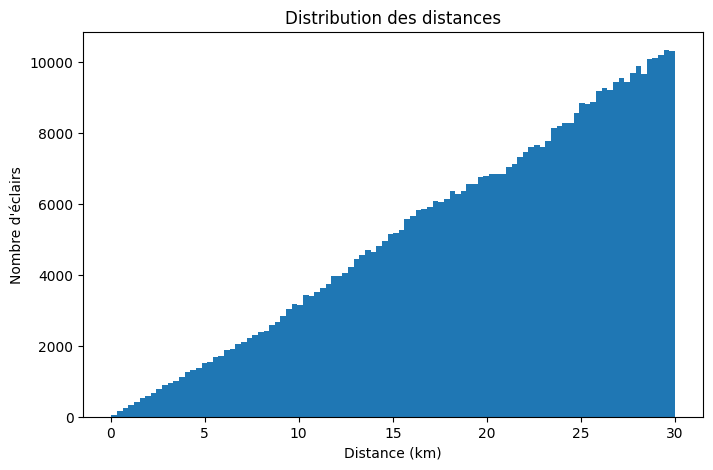

In [14]:
print(df["dist"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["dist"], bins=100)
plt.xlabel("Distance (km)")
plt.ylabel("Nombre d'éclairs")
plt.title("Distribution des distances")
plt.show()

In [15]:
df["date"] = pd.to_datetime(df["date"], utc=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

df["abs_amplitude"] = df["amplitude"].abs()

**Distribution par aéoroports**

écaires par aéoroport : airport
Pise        156718
Bastia      125919
Biarritz    115191
Ajaccio      72501
Nantes       36742
Name: count, dtype: int64
proportion d'écaires par aéoroport : airport
Pise        0.309065
Bastia      0.248326
Biarritz    0.227169
Ajaccio     0.142980
Nantes      0.072459
Name: proportion, dtype: float64


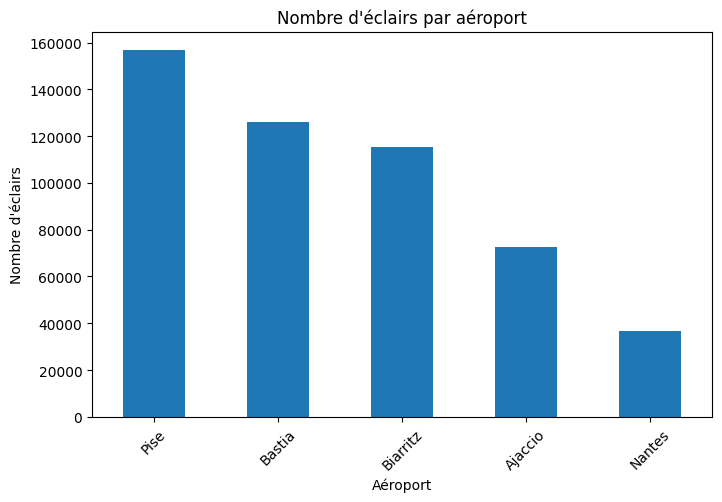

In [16]:
airport_counts = df["airport"].value_counts()
airport_counts_normalized = df["airport"].value_counts(normalize=True)
print(f"écaires par aéoroport : {airport_counts}")
print(f"proportion d'écaires par aéoroport : {airport_counts_normalized}")

plt.figure(figsize=(8, 5))
airport_counts.plot(kind="bar")
plt.xlabel("Aéroport")
plt.ylabel("Nombre d'éclairs")
plt.title("Nombre d'éclairs par aéroport")
plt.xticks(rotation=45)
plt.show()

Nantes rencontre beacoup moins d'éclaires que le reste des aéorports.

### Par Types d'éclaires

Nombre d'éclaires par catégorieicloud
True     378079
False    128992
Name: count, dtype: int64
Proportion d'éclaires par catégorieicloud
True     0.745614
False    0.254386
Name: proportion, dtype: float64


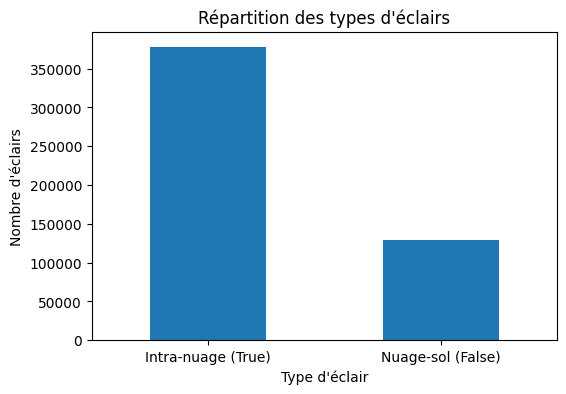

In [17]:
icloud_counts = df["icloud"].value_counts()
icloud_counts_normalized = df["icloud"].value_counts(normalize=True)

print(f"Nombre d'éclaires par catégorie{icloud_counts}")
print(f"Proportion d'éclaires par catégorie{icloud_counts_normalized}")

plt.figure(figsize=(6,4))
icloud_counts.plot(kind="bar")

plt.xlabel("Type d'éclair")
plt.ylabel("Nombre d'éclairs")
plt.title("Répartition des types d'éclairs")

plt.xticks(
    ticks=[0,1],
    labels=["Intra-nuage (True)", "Nuage-sol (False)"],
    rotation=0
)

plt.show()

Ceci nous dit que que un quart des éclaires sont Nuage-sol.
Ainsi, Nantes par exemple n'avait(en moyenne) que $\frac{36742}{4} = 9185$ éclaires alarmants tout au long de 8 ans.

### Type d éclairs par aéoroport

Nombre d'éclairs par aéroport: airport   icloud
Ajaccio   True       48453
          False      24048
Bastia    True       92610
          False      33309
Biarritz  True       93960
          False      21231
Nantes    True       27193
          False       9549
Pise      True      115863
          False      40855
Name: count, dtype: int64
Proportion d'éclairs par aéroport: airport   icloud
Ajaccio   True      0.668308
          False     0.331692
Bastia    True      0.735473
          False     0.264527
Biarritz  True      0.815689
          False     0.184311
Nantes    True      0.740107
          False     0.259893
Pise      True      0.739309
          False     0.260691
Name: proportion, dtype: float64


<Figure size 800x500 with 0 Axes>

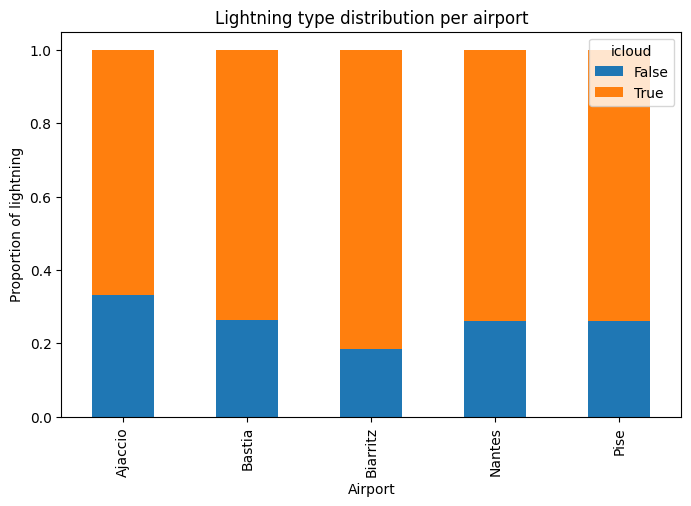

In [18]:
icloud_count_per_airport = df.groupby("airport")["icloud"].value_counts()
icloud_count_per_airport_normalize = df.groupby("airport")["icloud"].value_counts(normalize = True)

print(f"Nombre d'éclairs par aéroport: {icloud_count_per_airport}")
print(f"Proportion d'éclairs par aéroport: {icloud_count_per_airport_normalize}")

counts = df.groupby(["airport","icloud"]).size().unstack()
plt.figure(figsize=(8,5))
prop = counts.div(counts.sum(axis=1), axis=0)

prop.plot(kind="bar", stacked=True, figsize=(8,5))
plt.xlabel("Airport")
plt.ylabel("Proportion of lightning")
plt.title("Lightning type distribution per airport")
plt.legend(title = "icloud")
plt.show()

Les éclairs intra-nuages sont majoritaires autour de tous les aéroports,mais la proportion d’éclairs nuage-sol reste plus faible et varie légèrement selon les aéroports, Ajaccio semblant en présenter un peu plus que les autres et Biarritz un peu moins.

### Par amplitude

count    507071.000000
mean         -2.254868
std          20.252913
min        -429.500000
25%          -5.610000
50%          -1.560000
75%           4.620000
max         497.000000
Name: amplitude, dtype: float64


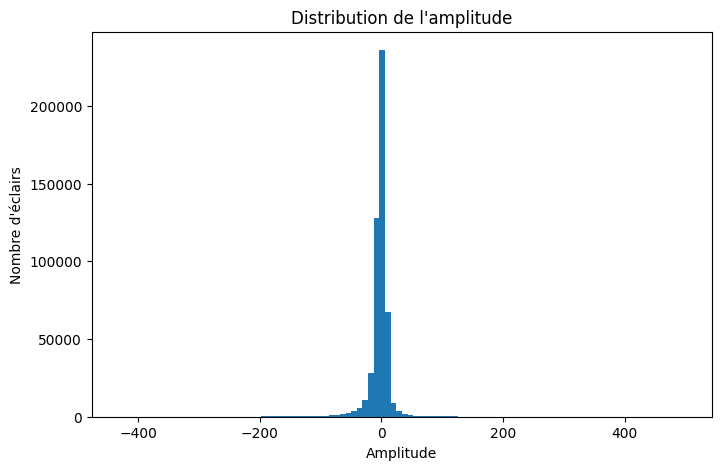

In [19]:
print(df["amplitude"].describe())
plt.figure(figsize=(8, 5))
plt.hist(df["amplitude"], bins=100)
plt.xlabel("Amplitude")
plt.ylabel("Nombre d'éclairs")
plt.title("Distribution de l'amplitude")
plt.show()

In [20]:
# df doit contenir 'airport', 'airport_alert_id', 'date', 'amplitude', 'dist', 'icloud'
df["date"] = pd.to_datetime(df["date"])

# créer table pour ML
features_list = []

for alert_id, alert_df in df[df["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    alert_df = alert_df.sort_values("date")
    alert_df["cum_lightnings"] = range(1, len(alert_df)+1)
    alert_df["cum_cloud_ground"] = (alert_df["icloud"]==False).cumsum()
    alert_df["cum_intra_cloud"] = (alert_df["icloud"]==True).cumsum()
    alert_df["cum_amplitude"] = alert_df["amplitude"].cumsum()
    alert_df["elapsed_min"] = (alert_df["date"] - alert_df["date"].iloc[0]).dt.total_seconds()/60
    alert_df["cum_max_distance"] = alert_df["dist"].cummax()
    
    features_list.append(alert_df)

df_features = pd.concat(features_list)

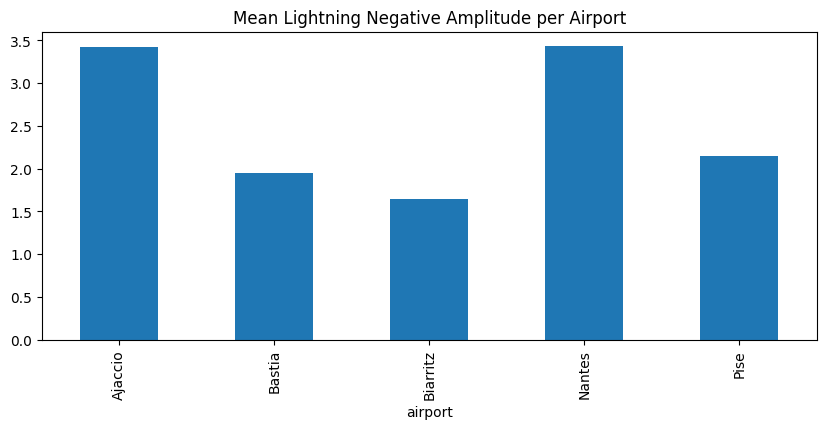

In [21]:

#Analyzing means

##mean amplitude
df["Flipped_Amplitude"] = - df["amplitude"]
df.groupby("airport")["Flipped_Amplitude"].mean().plot(kind="bar", figsize=(10,4), title="Mean Lightning Negative Amplitude per Airport")
plt.show()





count    507071.000000
mean          9.690992
std          17.926221
min           0.000000
25%           3.060000
50%           4.980000
75%           8.880000
max         497.000000
Name: abs_amplitude, dtype: float64


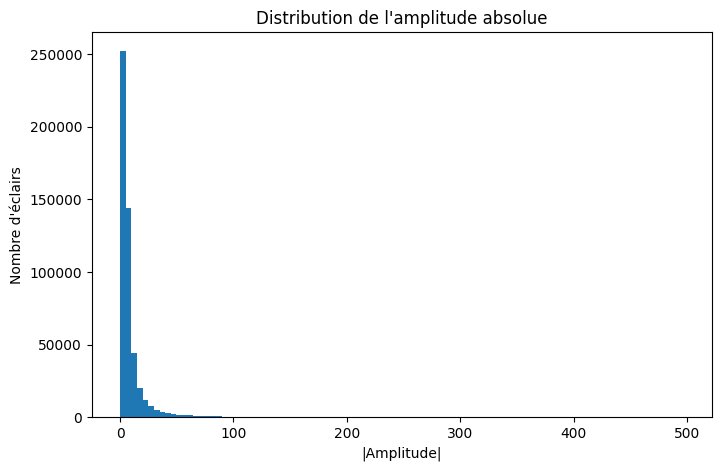

In [22]:
df["abs_amplitude"] = df["amplitude"].abs()
print(df["abs_amplitude"].describe())
plt.figure(figsize=(8, 5))
plt.hist(df["abs_amplitude"], bins=100)
plt.xlabel("|Amplitude|")
plt.ylabel("Nombre d'éclairs")
plt.title("Distribution de l'amplitude absolue")
plt.show()

Nombre d'éclairs positifs : 243894
Nombre d'éclairs négatifs : 263144
Proportion positifs : 0.48101720186652674
Proportion négatifs : 0.5189827981334733
amplitude
negatif    263177
positif    243894
Name: count, dtype: int64


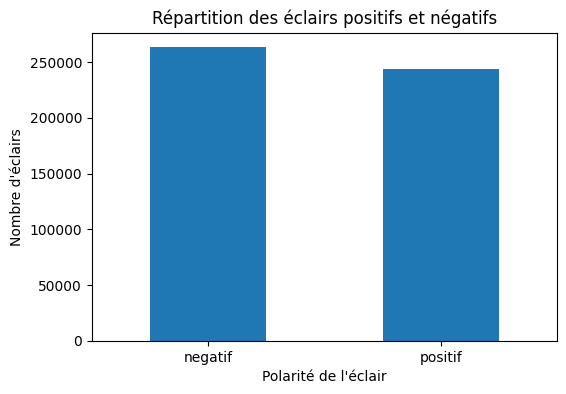

In [23]:
positive = (df["amplitude"] > 0).sum()
negative = (df["amplitude"] < 0).sum()

print("Nombre d'éclairs positifs :", positive)
print("Nombre d'éclairs négatifs :", negative)

total = positive + negative

print("Proportion positifs :", positive / total)
print("Proportion négatifs :", negative / total)

polarity_counts = df["amplitude"].apply(lambda x: "positif" if x > 0 else "negatif")

counts = polarity_counts.value_counts()

print(counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
counts.plot(kind="bar")

plt.xlabel("Polarité de l'éclair")
plt.ylabel("Nombre d'éclairs")
plt.title("Répartition des éclairs positifs et négatifs")

plt.xticks(rotation=0)

plt.show()

L’amplitude des éclairs présente une distribution centrée proche de zéro, avec une moyenne de −2.25 kA et une médiane de −1.56 kA.
Les valeurs extrêmes atteignent −429 kA et +497 kA, indiquant la présence d’éclairs très puissants mais rares.
L’analyse de la polarité montre une répartition relativement équilibrée entre éclairs positifs (48 %) et négatifs (52 %).
L’intensité absolue moyenne des éclairs est d’environ 9.7 kA, bien que la majorité des éclairs présentent des intensités inférieures à 10 kA.

In [24]:
df.groupby("icloud")["abs_amplitude"].describe()

,count,mean,std,min,25%,50%,75%,max
icloud,,,,,,,,
False,128992.0,22.771515,31.306475,0.0,6.55,12.43,25.01,497.0
True,378079.0,5.228214,4.279032,0.0,2.73,4.20,6.28,429.5


<Axes: title={'center': 'abs_amplitude'}, xlabel='icloud'>

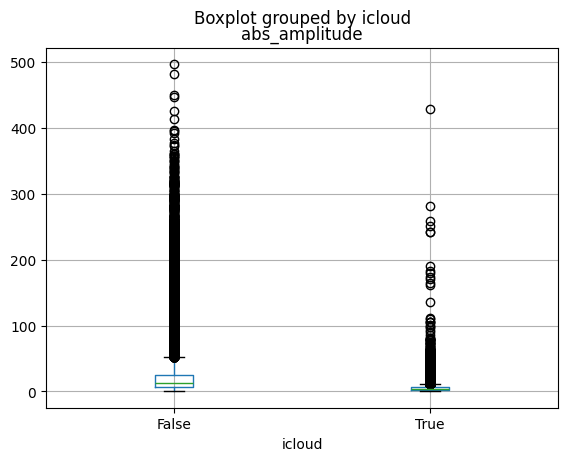

In [25]:
df.boxplot(column="abs_amplitude", by="icloud")

L’analyse de l’amplitude absolue montre une différence marquée entre les éclairs nuage-sol et les éclairs intra-nuage. Les éclairs nuage-sol présentent une intensité moyenne d’environ 22.8 kA, contre 5.2 kA pour les éclairs intra-nuage, avec une variance beaucoup plus grande (comme le montre le BoxPlot).
La médiane confirme cette différence (12.4 kA contre 4.2 kA).
Cette observation est cohérente avec les mécanismes physiques des éclairs : les décharges nuage-sol impliquent généralement des courants plus élevés et une variabilité plus importante.

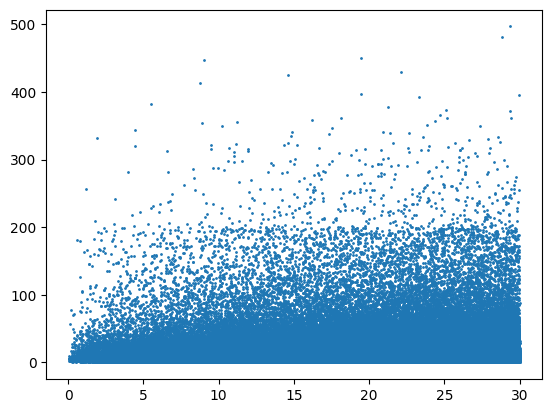

In [26]:
plt.scatter(df["dist"], df["abs_amplitude"], s=1)

In [27]:
df_alert = df[df["airport_alert_id"].notna()]

df_alert.groupby("icloud")["abs_amplitude"].describe()

,count,mean,std,min,25%,50%,75%,max
icloud,,,,,,,,
False,56599.0,22.783722,31.613084,0.0,6.465,12.25,24.94,450.0


Le nuage de points représentant l’intensité des éclairs (amplitude absolue) en fonction de leur distance à l’aéroport ne montre **pas de corrélation évidente** entre ces deux variables. Des éclairs de faible et de forte intensité sont observés à toutes les distances dans le rayon étudié (0–30 km). Cela suggère que la puissance d’un éclair n’est pas directement liée à sa distance par rapport à l’aéroport (ce qui a été attendu).

On observe également une distribution fortement concentrée près des faibles amplitudes, avec un nombre très important d’éclairs de faible intensité et seulement quelques événements très puissants. Cette forme triangulaire est caractéristique de phénomènes naturels où les événements extrêmes sont rares.

### Par Erreur de localisation

Erreur de localisation :
count    507071.000000
mean          1.025518
std           1.359688
min           0.016000
25%           0.107000
50%           0.245000
75%           1.538000
max           6.900000
Name: maxis, dtype: float64


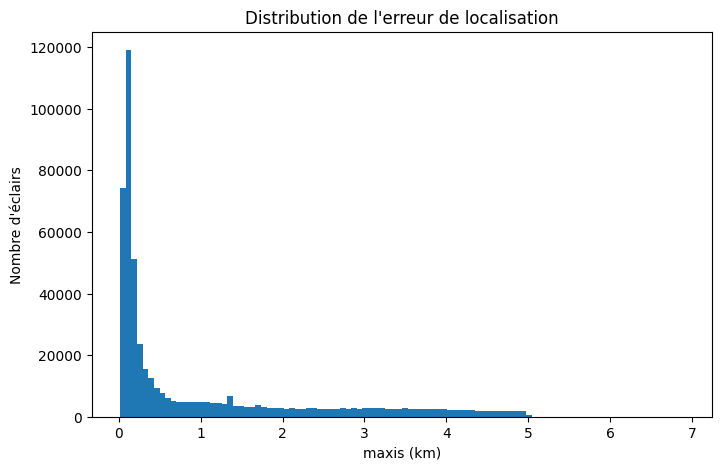

In [28]:
errors = df["maxis"].describe()
print(f"Erreur de localisation :")
print(errors)
plt.figure(figsize=(8, 5))
plt.hist(df["maxis"], bins=100)
plt.xlabel("maxis (km)")
plt.ylabel("Nombre d'éclairs")
plt.title("Distribution de l'erreur de localisation")
plt.show()

L’erreur de localisation des éclairs est généralement faible, avec une médiane d’environ 0.245 km. Cela signifie que la majorité des éclairs sont localisés avec une précision de quelques centaines de mètres. La distribution est toutefois asymétrique, avec quelques valeurs extrêmes atteignant près de 6.9 km, ce qui peut s’expliquer par des conditions de détection plus difficiles. Globalement, le système de localisation semble fournir des positions relativement précises pour la plupart des éclairs observés.

In [29]:
df[["dist", "maxis"]].corr()

,dist,maxis
dist,1.000000,-0.019166
maxis,-0.019166,1.000000


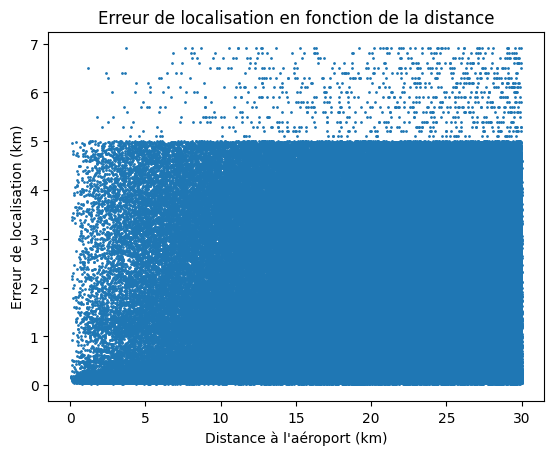

In [30]:
plt.scatter(df["dist"], df["maxis"], s=1)
plt.xlabel("Distance à l'aéroport (km)")
plt.ylabel("Erreur de localisation (km)")
plt.title("Erreur de localisation en fonction de la distance")
plt.show()

La corrélation entre la distance à l’aéroport (`dist`) et l’erreur de localisation (`maxis`) est très faible :

$$
\rho(dist, maxis) \approx -0.019
$$

Cette valeur est très proche de zéro, ce qui indique **l’absence de relation linéaire significative entre ces deux variables**.

Le nuage de points confirme cette observation : l’erreur de localisation reste globalement répartie de manière uniforme pour toutes les distances comprises entre 0 et 30 km. Autrement dit, la précision de la localisation des éclairs ne semble pas dépendre de leur distance à l’aéroport dans la zone étudiée.

On observe également que la majorité des erreurs de localisation se situent **en dessous de 5 km**, avec quelques valeurs extrêmes pouvant atteindre environ 7 km. Ces valeurs extrêmes restent rares et peuvent correspondre à des conditions de détection plus difficiles.

Cette analyse suggère que la variable `maxis` est **largement indépendante de la distance à l’aéroport** et reflète plutôt l’incertitude intrinsèque du système de détection et de localisation des éclairs.

### Par Azimuth

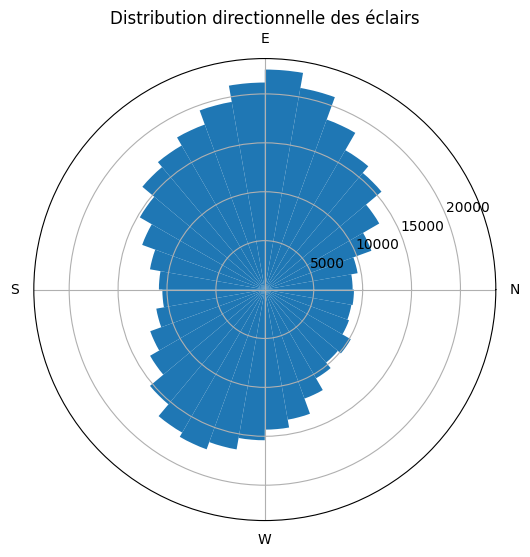

In [31]:
az = np.deg2rad(df["azimuth"])  # convertir degrés -> radians

plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection="polar")

ax.hist(az, bins=36)  # 36 bins = 10°

# définir les directions cardinales
ax.set_thetagrids([0, 90, 180, 270], labels=["N", "E", "S", "W"])

ax.set_title("Distribution directionnelle des éclairs")

plt.show()

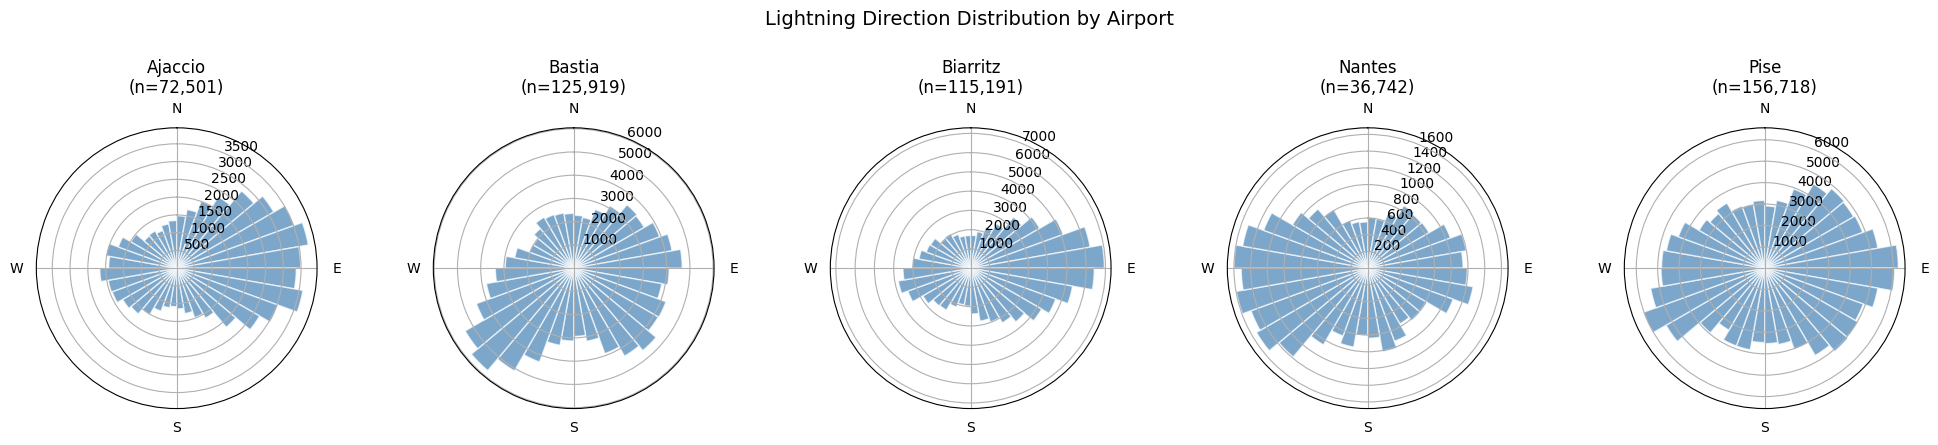

In [32]:
# cool plot, not too relevant
fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={'projection': 'polar'})
import numpy as np
for ax, (airport, airport_name) in zip(axes, enumerate(df['airport'].unique())):
    airport_data = df[df['airport'] == airport_name]
    
    # Convert azimuth to radians for polar plot
    azimuth_rad = np.deg2rad(airport_data['azimuth'])
    
    # Create histogram
    ax.hist(azimuth_rad, bins=36, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(f'{airport_name}\n(n={len(airport_data):,})')
    ax.set_theta_zero_location('N')  # Set North as 0°
    ax.set_theta_direction(-1)  # Clockwise direction
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(['N', 'E', 'S', 'W'])

plt.suptitle('Lightning Direction Distribution by Airport', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Azimuth
count    507071.000000
mean        168.806028
std          97.587294
min           0.000000
25%          85.240722
50%         156.717299
75%         251.482192
max         359.978549
Name: azimuth, dtype: float64


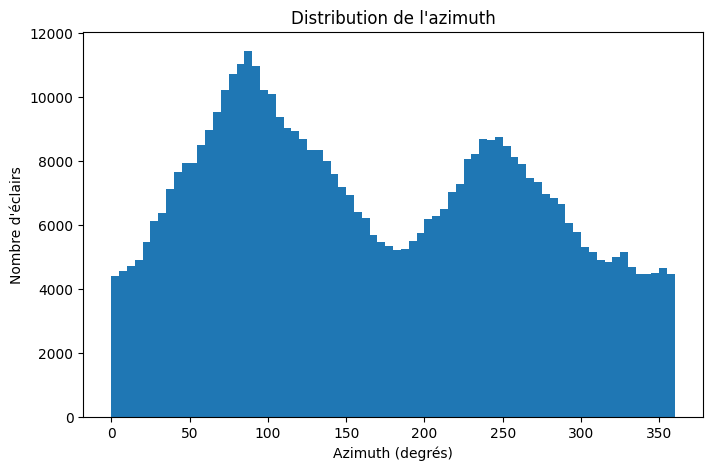

In [33]:
print("Azimuth")
print(df["azimuth"].describe())
plt.figure(figsize=(8, 5))
plt.hist(df["azimuth"], bins=72)  # 72 bins = tranches de 5 degrés
plt.xlabel("Azimuth (degrés)")
plt.ylabel("Nombre d'éclairs")
plt.title("Distribution de l'azimuth")
plt.show()

L'azimut représente la direction de l'éclair par rapport à l'aéroport, exprimée en degrés :
- 0° correspond au **Nord**
- 90° correspond à l'**Est**
- 180° correspond au **Sud**
- 270° correspond à l'**Ouest**

L'histogramme de l'azimut montre que les éclairs sont globalement répartis dans toutes les directions autour des aéroports. Bien que certaines directions présentent des variations dans le nombre d'occurrences, aucune direction ne semble dominer de manière marquée.

Les statistiques descriptives indiquent une moyenne d'environ **168°** et un écart-type d'environ **97°**, ce qui confirme une dispersion importante des directions.

Ainsi, les éclairs semblent se produire dans l'ensemble des directions autour des aéroports, sans dépendance directionnelle très forte dans ce dataset. Cette variable reflète donc principalement la **distribution spatiale des éclairs autour des aéroports**, mais ne met pas en évidence de direction privilégiée particulièrement dominante.

### Distribution temporelle

year
2016    105074
2017     58983
2018    116033
2019     55300
2020     55680
2021     38300
2022     77701
Name: count, dtype: int64


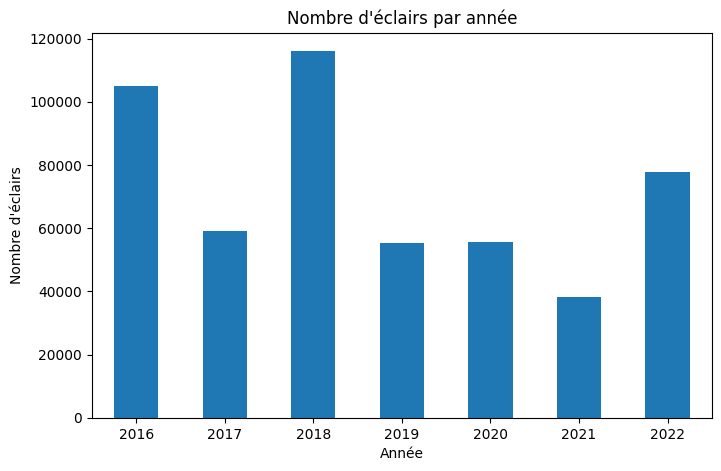

In [34]:
year_counts = df["year"].value_counts().sort_index()
print(year_counts)
plt.figure(figsize=(8, 5))
year_counts.plot(kind="bar")
plt.xlabel("Année")
plt.ylabel("Nombre d'éclairs")
plt.title("Nombre d'éclairs par année")
plt.xticks(rotation=0)
plt.show()

month
1       2973
2       4394
3       6005
4      10686
5      38304
6      65193
7      88435
8     134901
9      69215
10     62127
11     20322
12      4516
Name: count, dtype: int64


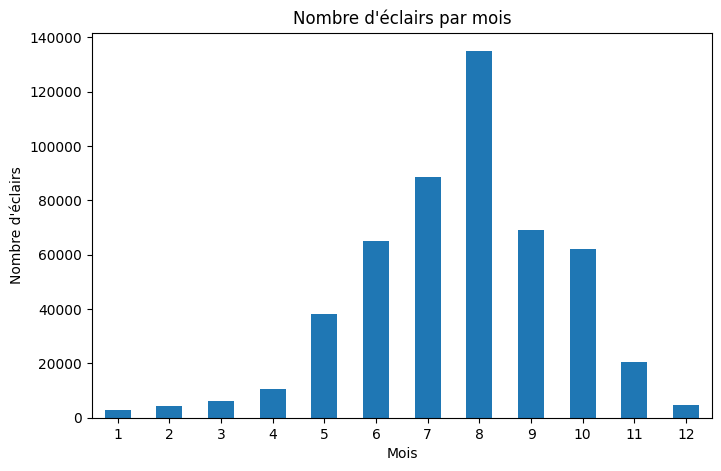

In [35]:
month_counts = df["month"].value_counts().sort_index()
print(month_counts)

plt.figure(figsize=(8, 5))
month_counts.plot(kind="bar")
plt.xlabel("Mois")
plt.ylabel("Nombre d'éclairs")
plt.title("Nombre d'éclairs par mois")
plt.xticks(rotation=0)
plt.show()

season
Été          288529
Automne      151664
Printemps     54995
Hiver         11883
Name: count, dtype: int64


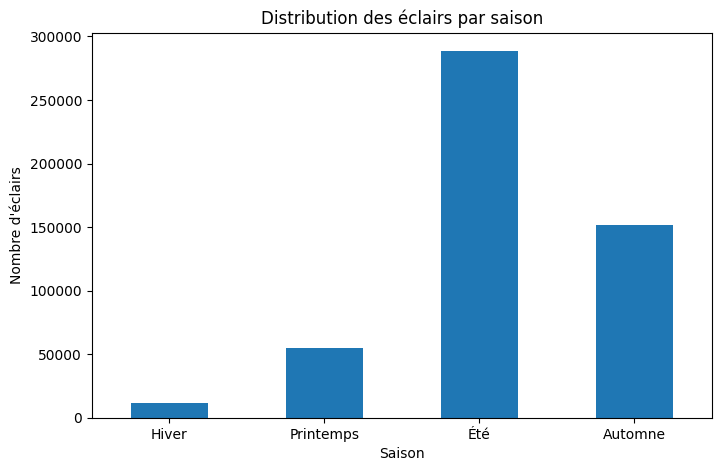

In [36]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Hiver"
    elif month in [3, 4, 5]:
        return "Printemps"
    elif month in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"

df["season"] = df["date"].dt.month.apply(get_season)

season_counts = df["season"].value_counts()

print(season_counts)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

season_counts = df["season"].value_counts().reindex(
    ["Hiver","Printemps","Été","Automne"]
)

season_counts.plot(kind="bar")

plt.xlabel("Saison")
plt.ylabel("Nombre d'éclairs")
plt.title("Distribution des éclairs par saison")

plt.xticks(rotation=0)

plt.show()

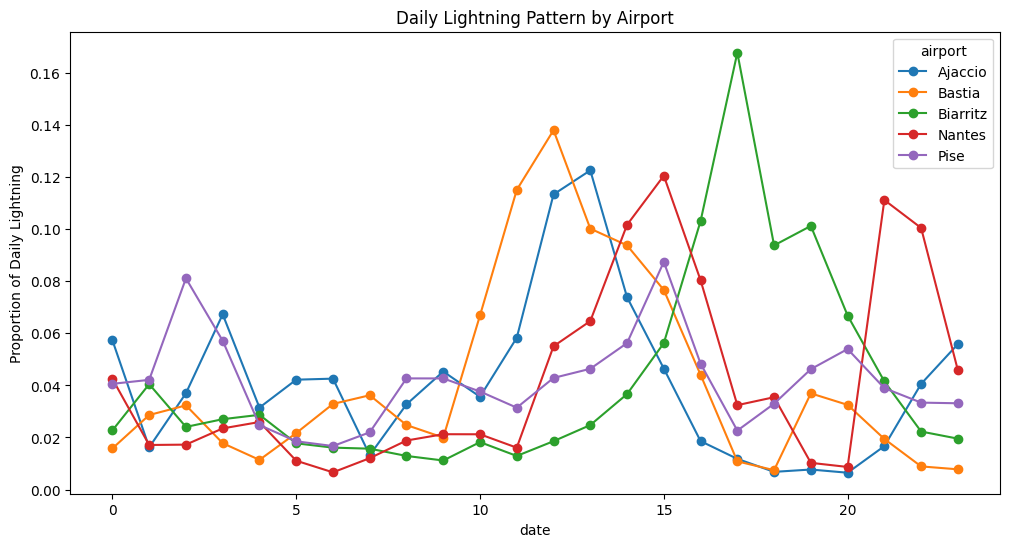

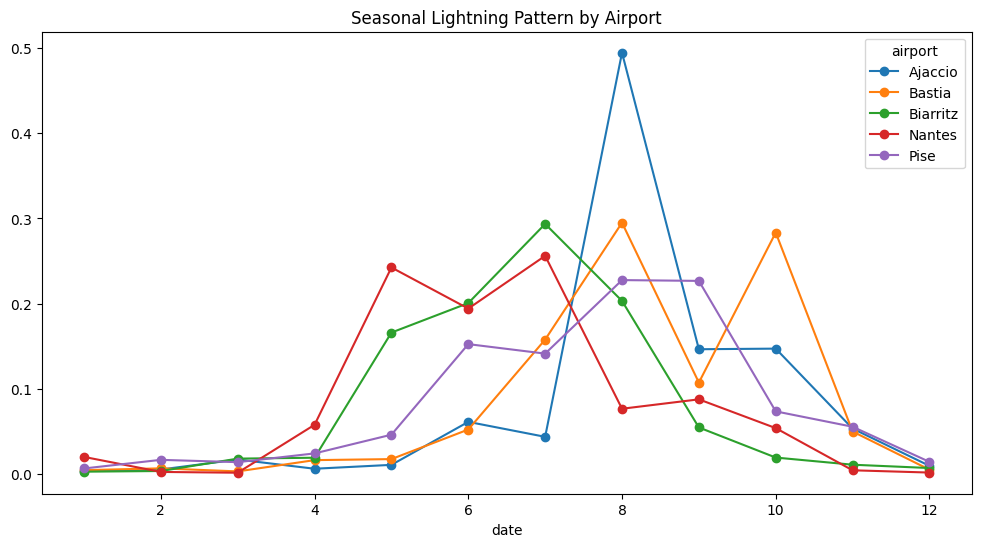

In [37]:
# Lightning activity by hour and airport, mostly afternoon
hourly_pattern = pd.crosstab(
    df['date'].dt.hour, 
    df['airport'], 
    values=df['amplitude'], 
    aggfunc='count', 
    normalize='columns'
)
hourly_pattern.plot(kind='line', figsize=(12,6), marker='o')
plt.title('Daily Lightning Pattern by Airport')
plt.ylabel('Proportion of Daily Lightning')
plt.show()

#Monthly patterns, mostle in august
monthly_pattern = pd.crosstab(
    df['date'].dt.month, 
    df['airport'], 
    values=df['amplitude'], 
    aggfunc='count', 
    normalize='columns'
)
monthly_pattern.plot(kind='line', figsize=(12,6), marker='o')
plt.title('Seasonal Lightning Pattern by Airport')
plt.show()

hour
0     16689
1     16674
2     22869
3     20051
4     11859
5     11146
6     11946
7     11214
8     14361
9     14555
10    19786
11    25723
12    36472
13    34000
14    33936
15    37627
16    29310
17    26281
18    18701
19    24493
20    21038
21    18631
22    15552
23    14157
Name: count, dtype: int64


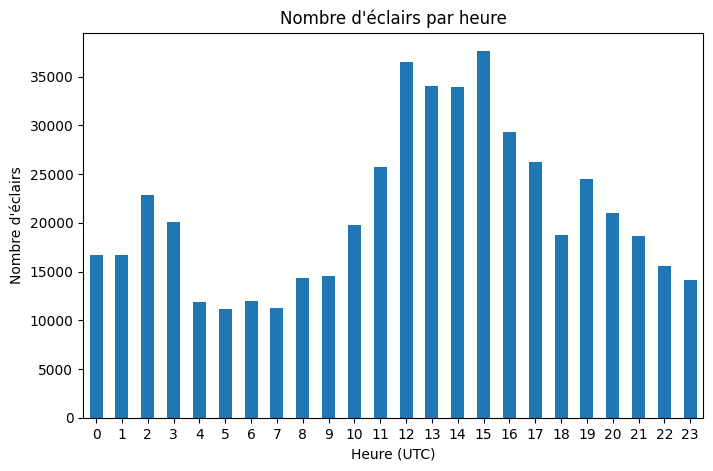

In [38]:
hour_counts = df["hour"].value_counts().sort_index()
print(hour_counts)

plt.figure(figsize=(8, 5))
hour_counts.plot(kind="bar")
plt.xlabel("Heure (UTC)")
plt.ylabel("Nombre d'éclairs")
plt.title("Nombre d'éclairs par heure")
plt.xticks(rotation=0)
plt.show()

**Distribution par année**

Le nombre d’éclairs observés varie fortement d’une année à l’autre. Certaines années présentent une activité électrique beaucoup plus importante que d’autres, notamment **2016 et 2018**, qui comptent le plus grand nombre d’éclairs dans le dataset. À l’inverse, **2021** présente une activité nettement plus faible.

Ces variations interannuelles peuvent être liées aux conditions météorologiques globales, certaines années étant plus propices au développement d’orages que d’autres.

---

**Distribution par mois**

La distribution mensuelle montre une **forte saisonnalité** de l’activité orageuse. Les éclairs sont très rares durant les mois d’hiver (janvier à mars), puis leur fréquence augmente progressivement au printemps.

L’activité atteint un **maximum durant l’été**, avec un pic très marqué au **mois d’août**, suivi de juillet et septembre. Après cette période, l’activité diminue progressivement durant l’automne.

Cette distribution est cohérente avec les mécanismes météorologiques : les orages se développent plus facilement lorsque l’atmosphère est instable et chaude, ce qui est typiquement le cas en été.

---

**Distribution par saison**

L’analyse par saison confirme cette tendance :

- **Été** : très forte activité orageuse, représentant la majorité des éclairs observés.
- **Automne** : activité encore importante mais plus faible que durant l’été.
- **Printemps** : activité modérée.
- **Hiver** : très faible activité électrique.

Cela montre que les éclairs sont principalement concentrés durant la **période estivale**, ce qui est typique des régions tempérées.

---

**Distribution par heure**

La distribution horaire révèle un **cycle journalier de l’activité orageuse**. Le nombre d’éclairs augmente progressivement à partir de la fin de la matinée et atteint un maximum durant l’**après-midi et le début de soirée** (environ entre 12h et 17h UTC).

Cette observation est cohérente avec la dynamique des orages convectifs : le réchauffement diurne de la surface favorise l’instabilité atmosphérique et la formation d’orages dans l’après-midi.

---

**Conclusion**

L’ensemble de ces analyses met en évidence une **forte structure temporelle de l’activité électrique**, caractérisée par :

- une forte **saisonnalité** (pic en été),
- une **variabilité interannuelle**,
- et un **cycle journalier** avec un maximum d’activité durant l’après-midi (qui reste moins significatives que le reste de cadres temp.


**By severity**

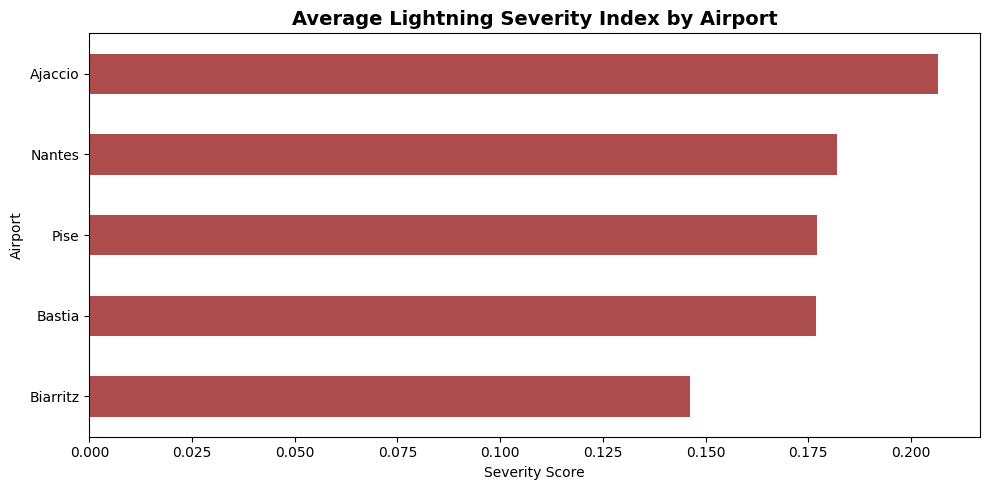

In [39]:
# Analyse de la sévérité des éclairs en combinant plusieurs facteurs
# On construit un indice de sévérité basé sur :
# - l'intensité de l'éclair
# - le type d'éclair (nuage-sol)
# - la proximité de l'aéroport

df_sev = df.copy()

# Valeur absolue de l'amplitude
df_sev["abs_amplitude"] = df_sev["amplitude"].abs()

# Normalisation de l'intensité
df_sev["amp_norm"] = df_sev["abs_amplitude"] / df_sev["abs_amplitude"].max()

# Variable indiquant un éclair nuage-sol
df_sev["ground_flash"] = (df_sev["icloud"] == False).astype(int)

# Proximité de l'aéroport (plus proche = score plus élevé)
df_sev["distance_score"] = 1 - (df_sev["dist"] / df_sev["dist"].max())

# Indice de sévérité combiné
df_sev["severity_score"] = (
    0.4 * df_sev["amp_norm"] +
    0.4 * df_sev["ground_flash"] +
    0.2 * df_sev["distance_score"]
)

# Sévérité moyenne par aéroport
severity_by_airport = df_sev.groupby("airport")["severity_score"].mean().sort_values()

# Visualisation
severity_by_airport.plot(kind="barh", figsize=(10,5), color="darkred", alpha=0.7)

plt.title("Average Lightning Severity Index by Airport", fontsize=14, fontweight="bold")
plt.xlabel("Severity Score")
plt.ylabel("Airport")

plt.tight_layout()
plt.show()

Afin de comparer l'intensité potentielle de l'activité orageuse autour des différents aéroports, un **indice de sévérité des éclairs** a été construit en combinant plusieurs facteurs :

- **l'intensité de l'éclair**, mesurée par la valeur absolue de l'amplitude et normalisée,
- **le type d'éclair**, les éclairs nuage-sol étant considérés comme plus critiques pour les opérations aéroportuaires,
- **la distance à l'aéroport**, les éclairs proches étant plus susceptibles d'impacter les opérations.

L'indice de sévérité est défini comme une combinaison pondérée de ces facteurs :

- 40 % intensité de l'éclair
- 40 % présence d'un éclair nuage-sol
- 20 % proximité de l'aéroport

Les résultats montrent que **Ajaccio** présente la sévérité moyenne la plus élevée, suggérant des éclairs en moyenne plus intenses ou plus proches de l'aéroport.  
Les aéroports de **Nantes, Bastia et Pise** présentent des niveaux de sévérité relativement comparables, tandis que **Biarritz** apparaît comme l'aéroport ayant l'activité électrique moyenne la moins intense selon cet indice.

Il convient toutefois de noter que cet indice reste **heuristique**, les poids ayant été choisis de manière empirique afin de capturer les principales dimensions du risque lié à l'activité électrique.

**Distribution of Time between Strikes**

Time Between Lightning Strikes (minutes):
count    53972.000000
mean         1.455535
std          3.197253
min          0.000000
25%          0.116667
50%          0.400000
75%          1.283333
max         29.933333
Name: time_to_next, dtype: float64


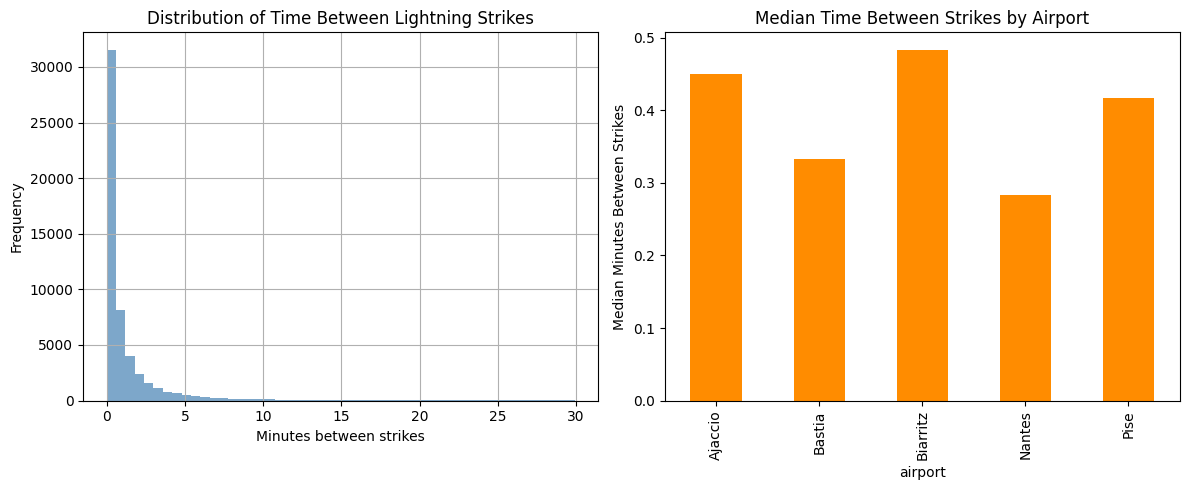

In [40]:
#time between strikes analysis in minutes
# Calculate time between consecutive lightning strikes in each alert
def calculate_intervals(group):
    group = group.sort_values('date')
    group['time_to_next'] = group['date'].diff().dt.total_seconds() / 60
    return group

df_with_intervals = df[df['airport_alert_id'].notna()].groupby(
    ['airport', 'airport_alert_id']
).apply(calculate_intervals)

# Analyze intervals
print("Time Between Lightning Strikes (minutes):")
print(df_with_intervals['time_to_next'].describe())

# Plot distribution
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
df_with_intervals['time_to_next'].hist(bins=50, color='steelblue', alpha=0.7)
plt.xlabel('Minutes between strikes')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Lightning Strikes')

plt.subplot(1,2,2)
df_with_intervals.groupby('airport')['time_to_next'].median().plot(kind='bar', color='darkorange')
plt.ylabel('Median Minutes Between Strikes')
plt.title('Median Time Between Strikes by Airport')
plt.tight_layout()
plt.show()

**Lightning Hotspots**

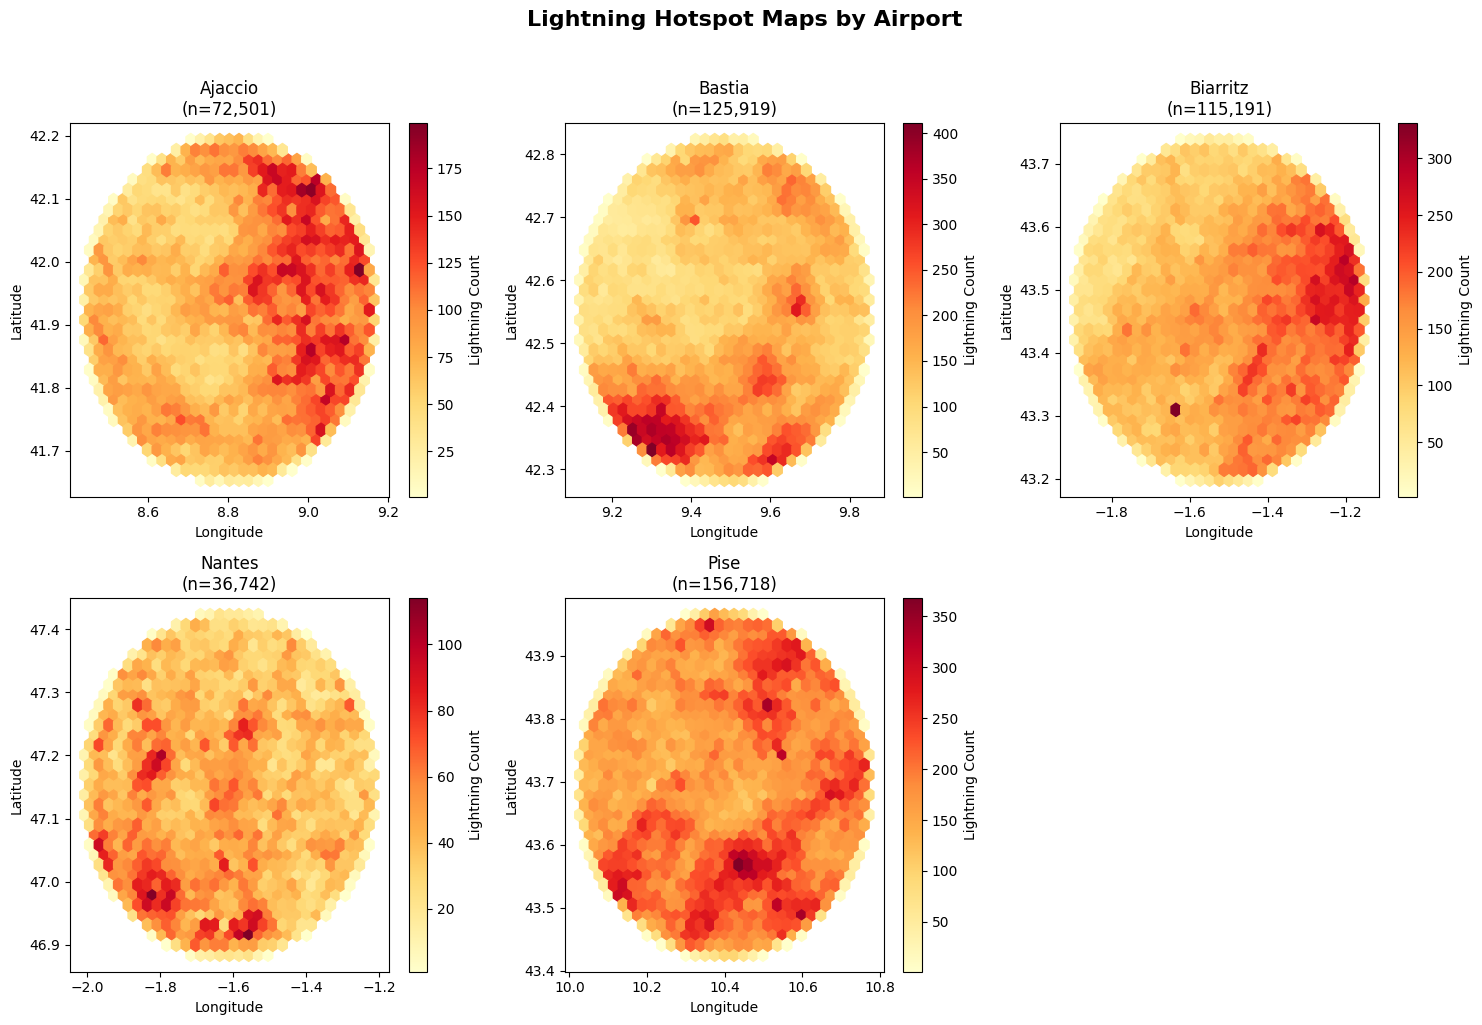

In [41]:
# Create 2D histogram of lightning locations
#cool figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, airport in enumerate(df['airport'].unique()):
    airport_data = df[df['airport'] == airport]
    
    #create hexbin  cool plot
    hb = axes[idx].hexbin(
        airport_data['lon'], 
        airport_data['lat'],
        gridsize=30,
        cmap='YlOrRd',
        mincnt=1
    )
    axes[idx].set_title(f'{airport}\n(n={len(airport_data):,})')
    axes[idx].set_xlabel('Longitude')
    axes[idx].set_ylabel('Latitude')
    plt.colorbar(hb, ax=axes[idx], label='Lightning Count')


axes[-1].remove()#remove empty subplot
plt.suptitle('Lightning Hotspot Maps by Airport', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


La figure ci-dessus présente des **cartes de densité spatiale des éclairs** autour de chaque aéroport, construites à l'aide d'un histogramme hexagonal (hexbin). Chaque hexagone représente une zone géographique, et sa couleur indique le **nombre d'éclairs détectés dans cette zone**.

Plusieurs observations peuvent être faites :

- L'activité électrique n'est **pas uniformément répartie** autour des aéroports. Certaines zones présentent une concentration nettement plus élevée d'éclairs, formant des **hotspots d'activité orageuse**.
- Ces zones de forte densité peuvent être liées à des facteurs météorologiques ou géographiques, comme la **topographie locale, la proximité de la mer ou les trajectoires dominantes des systèmes orageux**.
- Les aéroports présentent des **structures spatiales différentes** : par exemple, certaines zones autour de **Ajaccio et Pise** montrent des concentrations plus marquées, tandis que d'autres aéroports présentent une distribution plus diffuse.
- Le nombre total d'éclairs observés varie également entre les aéroports (indiqué par \(n\) dans chaque sous-figure), ce qui reflète des **conditions climatiques régionales différentes**.

Ces cartes permettent donc d'identifier les **zones où l'activité électrique est la plus fréquente autour des aéroports**, ce qui peut être utile pour mieux comprendre la dynamique spatiale des orages et leurs impacts potentiels sur les opérations aéroportuaires.

In [42]:
# Trier le DataFrame par aéroport et date
df = df.sort_values(["airport", "date"])

In [43]:
# Calculer la différence de temps entre les éclairs consécutifs pour chaque aéroport
time_diff = df.groupby("airport")["date"].diff()

# Identifier les éclairs qui appartiennent à la même tempête (différence de temps <= 20 minutes)
df["storm_id"] = (time_diff > pd.Timedelta(minutes=30)).groupby(df["airport"]).cumsum()

In [44]:
# Agréger les données par aéroport et tempête
storms = (
    df.groupby(["airport","storm_id"])
    .agg(
        start_time=("date","min"),
        end_time=("date","max"),
        n_lightnings=("lightning_id","count"),
        nb_cloud_ground=("icloud", lambda x: (x==False).sum()),
        nb_intra_cloud=("icloud", lambda x: (x==True).sum()),
        max_distance=("dist","max"),
        mean_amplitude=("amplitude","mean")
    )
)

# Calculer la durée de chaque tempête en minutes
storms["duration_min"] = (
    storms["end_time"] - storms["start_time"]
).dt.total_seconds()/60

storms.to_csv("storms.csv")

In [45]:
# Agréger les données par aéroport et alerte
alerts = (
    df[df["airport_alert_id"].notna()]
    .groupby(["airport","airport_alert_id"])
    .agg(
        start_time=("date","min"),
        end_time=("date","max"),
        n_lightnings=("lightning_id","count"),
        nb_cloud_ground=("icloud", lambda x: (x==False).sum()),
        nb_intra_cloud=("icloud", lambda x: (x==True).sum()),
        max_distance=("dist","max"),
        mean_amplitude=("amplitude","mean"),
        start_month=("date",lambda x: x.min().month),
        start_hour=("date",lambda x: x.min().hour)
    )
)

# Calculer la durée de chaque alerte en minutes
alerts["duration_min"] = (
    alerts["end_time"] - alerts["start_time"]
).dt.total_seconds()/60

alerts.to_csv("alerts.csv")

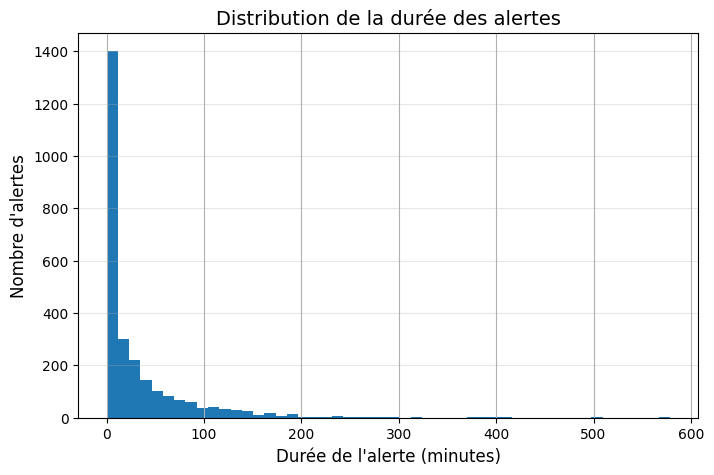

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

alerts["duration_min"].hist(bins=50)

plt.title("Distribution de la durée des alertes", fontsize=14)
plt.xlabel("Durée de l'alerte (minutes)", fontsize=12)
plt.ylabel("Nombre d'alertes", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.show()

L'histogramme montre que la majorité des alertes ont une **durée relativement courte**, avec une forte concentration d'événements durant les premières dizaines de minutes.

La distribution est fortement **asymétrique (skewed à droite)** :  
- la plupart des alertes durent **moins d'une heure**,  
- mais certaines alertes peuvent durer **plusieurs heures**, avec quelques cas extrêmes dépassant 400 à 500 minutes.

Cela suggère que la plupart des épisodes orageux autour des aéroports sont **brefs mais intenses**, tandis que certains systèmes convectifs plus organisés peuvent maintenir une activité électrique pendant une période beaucoup plus longue.

Cette asymétrie est importante pour la modélisation, car elle indique la présence de **valeurs extrêmes** qui peuvent influencer certaines méthodes statistiques.

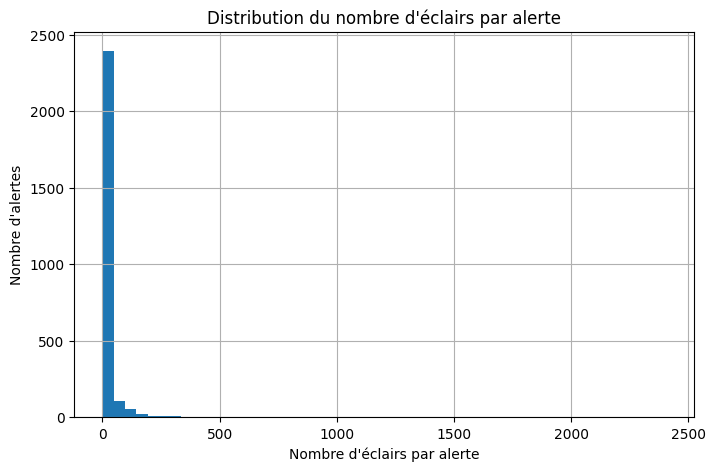

In [47]:
# Histogramme du nombre d'éclairs
plt.figure(figsize=(8,5))
alerts["n_lightnings"].hist(bins=50)
plt.xlabel("Nombre d'éclairs par alerte")
plt.ylabel("Nombre d'alertes")
plt.title("Distribution du nombre d'éclairs par alerte")
plt.show()

La distribution du nombre d'éclairs par alerte présente également une **forte asymétrie**.

La majorité des alertes contiennent **un nombre relativement faible d’éclairs**, ce qui correspond probablement à des épisodes orageux courts ou peu actifs.

Cependant, certaines alertes présentent **un très grand nombre d’éclairs**, ce qui peut correspondre à des orages particulièrement intenses ou durables.

Cette distribution indique que l'activité électrique est **très variable d'une alerte à l'autre**, avec quelques épisodes particulièrement actifs qui concentrent un grand nombre d'éclairs.

Ces observations suggèrent que les alertes peuvent être classées en différentes catégories :
- alertes **courtes et peu actives**,
- alertes **longues et fortement actives**.

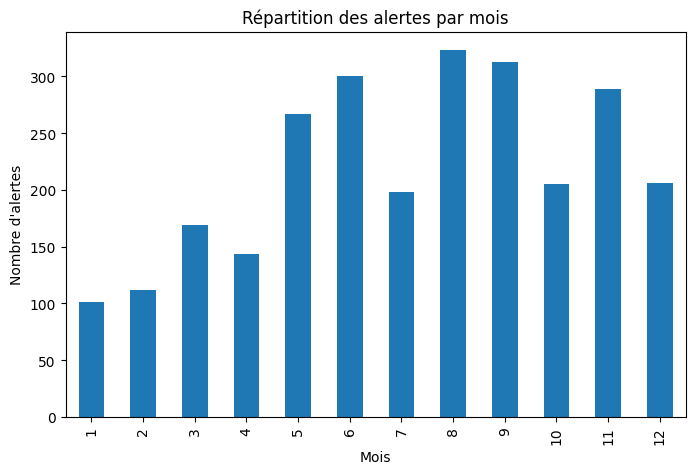

Médiane de durée par mois :
 start_month
1      1.200000
2      1.025000
3      2.133333
4      4.275000
5      8.866667
6     10.383333
7     19.700000
8     20.783333
9     15.233333
10    11.600000
11     6.516667
12     3.041667
Name: duration_min, dtype: float64


In [48]:
# Barplot des mois de début
plt.figure(figsize=(8,5))
alerts["start_month"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Mois")
plt.ylabel("Nombre d'alertes")
plt.title("Répartition des alertes par mois")
plt.show()

# Médiane de durée par mois
median_duration = alerts.groupby("start_month")["duration_min"].median()
print("Médiane de durée par mois :\n", median_duration)

La distribution mensuelle des alertes montre une **forte saisonnalité de l'activité orageuse**.

Le nombre d'alertes augmente progressivement au printemps et atteint un maximum durant les mois d'été, en particulier **entre juin et septembre**. Cette période correspond aux conditions atmosphériques les plus favorables à la formation d'orages convectifs.

À l'inverse, les mois d'hiver présentent un nombre nettement plus faible d'alertes, ce qui reflète la moindre activité orageuse durant cette période.

Cette saisonnalité confirme les observations faites précédemment sur la distribution temporelle des éclairs et souligne l'importance des variables temporelles (mois, saison) dans l'analyse et la modélisation de l'activité orageuse.

Durée médiane des alertes selon le mois:

L'analyse de la durée médiane des alertes par mois montre que les alertes tendent à être **plus longues durant les mois d'été**.

La durée médiane des alertes augmente progressivement du printemps jusqu'à l'été, atteignant un maximum autour des mois de **juillet et août**. Cela suggère que les orages estivaux sont non seulement plus fréquents, mais également **plus persistants**.

À l'inverse, les alertes observées durant les mois d'hiver sont généralement **plus courtes**, ce qui est cohérent avec une activité orageuse moins organisée et moins intense.

Cette observation renforce l'idée que la **saison joue un rôle majeur dans la dynamique des épisodes orageux**, tant en termes de fréquence que de durée.

In [49]:
for alert_id, alert_df in df[df["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    alert_df["cum_lightnings"] = range(1, len(alert_df)+1)
    alert_df["cum_cloud_ground"] = (alert_df["icloud"]==False).cumsum()
    alert_df["cum_intra_cloud"] = (alert_df["icloud"]==True).cumsum()
    alert_df["cum_amplitude"] = alert_df["amplitude"].cumsum()
    alert_df["elapsed_min"] = (alert_df["date"] - alert_df["date"].iloc[0]).dt.total_seconds()/60
    alert_df["cum_max_distance"] = alert_df["dist"].cummax()

In [50]:
#alerts["duration_min"] - sample_elapsed_min

## Conclusion de l'analyse exploratoire des données

L'analyse exploratoire a permis d'identifier plusieurs caractéristiques importantes concernant la structure du dataset, les propriétés physiques des éclairs ainsi que la dynamique des alertes orageuses autour des aéroports.

### Synthèse des observations

| Aspect analysé | Résultat observé | Interprétation |
|----------------|-----------------|---------------|
| Taille du dataset | ≈ 507 000 éclairs observés | Dataset volumineux couvrant plusieurs années et plusieurs aéroports |
| Distance à l'aéroport (`dist`) | Les informations d'alerte ne sont renseignées que pour `dist < 20 km` | Les alertes concernent uniquement les éclairs proches de l'aéroport |
| Type d’éclair (`icloud`) | ≈ 74 % intra-nuage et ≈ 26 % nuage-sol | Les éclairs nuage-sol représentent environ **un quart des éclairs** |
| Intensité des éclairs (`amplitude`) | Moyenne ≈ -2.25 kA, distribution centrée autour de 0 | Répartition presque équilibrée entre polarités positives et négatives |
| Intensité absolue (`abs_amplitude`) | Intensité moyenne ≈ 9.7 kA | La majorité des éclairs ont une intensité relativement faible |
| Intensité selon le type d’éclair | Moyenne ≈ 22.8 kA pour nuage-sol contre ≈ 5.2 kA pour intra-nuage | Les éclairs nuage-sol sont **beaucoup plus puissants** |
| Polarité des éclairs | ≈ 48 % positifs et ≈ 52 % négatifs | Répartition relativement équilibrée des polarités |
| Erreur de localisation (`maxis`) | Médiane ≈ 0.245 km, moyenne ≈ 1.03 km, max ≈ 6.9 km | Localisation généralement précise mais **distribution fortement asymétrique avec quelques valeurs extrêmes** |
| Corrélation distance–erreur | Corrélation ≈ -0.02 | L'erreur de localisation est **indépendante de la distance à l'aéroport** |
| Direction (`azimuth`) | Distribution globalement uniforme | Pas de direction dominante claire des éclairs |
| Distribution spatiale | Présence de zones de forte concentration d'éclairs autour des aéroports | Les cartes de densité révèlent des **hotspots d'activité orageuse**, probablement liés aux conditions météorologiques locales ou à la topographie |
| Sévérité des éclairs | Différences observées entre aéroports selon un indice combinant intensité, type d’éclair et distance | Certaines zones présentent des épisodes orageux potentiellement **plus intenses ou plus proches des infrastructures** |
| Variabilité interannuelle | Nombre d'éclairs très variable selon les années | Les conditions météorologiques varient d'une année à l'autre |
| Distribution mensuelle | Pic marqué en juillet–août | Forte saisonnalité de l'activité orageuse |
| Distribution saisonnière | Été largement dominant | La majorité des éclairs se produit durant l'été |
| Cycle journalier | Pic d'activité entre midi et fin d'après-midi | Activité orageuse liée au réchauffement diurne |
| Durée des alertes | Majorité des alertes de courte durée mais présence de longues alertes | Distribution fortement asymétrique avec quelques épisodes orageux persistants |
| Nombre d'éclairs par alerte | La plupart des alertes contiennent peu d'éclairs mais certaines sont très actives | Activité électrique très variable selon les épisodes orageux |
| Répartition des alertes par mois | Forte concentration entre juin et septembre | Les alertes suivent la même saisonnalité que les éclairs |
| Durée médiane des alertes par mois | Alertes plus longues durant l'été | Les orages estivaux sont à la fois plus fréquents et plus persistants |

---

### Variables potentiellement importantes pour la modélisation

Les analyses précédentes suggèrent que plusieurs variables pourraient être particulièrement pertinentes pour la modélisation :

- **distance à l'aéroport (`dist`)**
- **type d'éclair (`icloud`)**
- **intensité de l'éclair (`abs_amplitude`)**
- **polarité de l'éclair**
- **variables temporelles** :
  - mois
  - saison
  - heure de la journée
- **aéroport concerné**
- **caractéristiques spatiales** liées aux zones de forte activité orageuse
- **dynamique des alertes** :
  - durée de l'alerte
  - nombre d'éclairs dans l'alerte
  - temps entre deux éclairs

---

### Conclusion générale

L'analyse met en évidence une **structure spatio-temporelle marquée de l'activité électrique**, caractérisée par une forte saisonnalité, un cycle journalier typique des orages convectifs et des zones géographiques présentant des concentrations élevées d'éclairs.

Les éclairs nuage-sol, bien que représentant environ **un quart des observations**, présentent des intensités nettement plus élevées que les éclairs intra-nuage et jouent un rôle central dans les alertes aéroportuaires.

L'analyse spatiale révèle également l'existence de **hotspots d'activité électrique** autour de certains aéroports, suggérant que la géographie locale et les conditions météorologiques régionales influencent la distribution des éclairs.

Enfin, l'étude de la durée et de l'intensité des alertes montre que l'activité orageuse est **très hétérogène**, avec de nombreux épisodes courts et quelques événements beaucoup plus longs et intenses.

Ces observations fournissent une base solide pour la construction de modèles prédictifs visant à mieux comprendre et anticiper la fin de l'activité orageuse autour des aéroports.

# Pipeline de préparation des données et de modélisation pour la prédiction de la fin d’un orage

## Objectif du projet

Notre objectif n’est pas simplement de décrire les éclairs, mais de **prédire si un strike donné est le dernier strike nuage-sol de l’alerte**, c’est-à-dire détecter si l’orage est en train de se terminer.

La variable cible est donc :

- `is_last_lightning_cloud_ground`

Cette variable doit être utilisée comme **target `y`** et **jamais comme feature**, sinon le modèle aurait directement accès à la réponse, ce qui créerait un **data leakage**.

---

# Étape 1 — Nettoyage, typage et préparation initiale du dataset

## But de cette étape

Avant de créer des features avancées, il faut partir d’une base propre, cohérente et exploitable.  
Cette étape a pour but de :

1. travailler sur une **copie** du dataset original, pour ne jamais modifier la donnée brute ;
2. corriger les types de colonnes ;
3. enlever les lignes inutilisables pour le modèle supervisé ;
4. éliminer quelques valeurs aberrantes susceptibles de perturber l’apprentissage ;
5. préparer certaines variables simples comme `is_cloud_ground` ;
6. encoder les variables catégorielles, notamment l’aéroport.

Voir le code ci dessous

**Construcion de la base du model**

In [59]:
df_model = df.copy()

# ==========================================================
# 1. Transtypage
# ==========================================================
# Conversion de la date en datetime pandas.
# Les dates d'origine sont supposées en UTC.
# errors="coerce" transforme les dates invalides en NaT.
df_model["date"] = pd.to_datetime(df_model["date"], utc=True, errors="coerce")

# Conversion vers l'heure locale de Paris pour uniformiser l'analyse temporelle.
df_model["date"] = df_model["date"].dt.tz_convert("Europe/Paris")

# Liste des colonnes qui doivent être numériques.
num_cols = ["lon", "lat", "amplitude", "maxis", "dist", "azimuth"]

# Conversion explicite des colonnes numériques.
# Toute valeur non convertible devient NaN.
for col in num_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Suppression des lignes où la date ou une variable numérique utile manque.
df_model = df_model.dropna(subset=["date"] + num_cols)

# Suppression des lignes où le type d'éclair (icloud) est manquant.
df_model = df_model.dropna(subset=["icloud"])


# ==========================================================
# 2. Nettoyage des valeurs aberrantes
# ==========================================================
# On retire les amplitudes extrêmes jugées aberrantes d'après l'EDA.
df_model = df_model[df_model["amplitude"].abs() < 300]

# On retire les éclairs trop éloignés.
df_model = df_model[df_model["dist"] < 200]

# On retire les erreurs de localisation trop grandes.
df_model = df_model[df_model["maxis"] < 10]


# ==========================================================
# 3. Variables de base
# ==========================================================
# On crée une variable plus parlante :
# 1 = cloud-ground (nuage-sol), 0 = intra-nuage.
df_model["is_cloud_ground"] = (~df_model["icloud"]).astype(int)

# On garde une copie texte du nom de l'aéroport.
# Elle servira pour les groupby même après le one-hot encoding final.
df_model["airport_name"] = df_model["airport"]


# ==========================================================
# 4. Tri chronologique AVANT la reconstruction des tempêtes
# ==========================================================
# On trie par aéroport puis par date pour garantir un ordre temporel correct.
df_model = df_model.sort_values(["airport_name", "date"]).reset_index(drop=True)


# ==========================================================
# 5. Construction du storm_id
# ==========================================================
# On calcule l'écart de temps avec l'éclair précédent, à l'intérieur de chaque aéroport.
time_diff = df_model.groupby("airport_name")["date"].diff()

# Si l'écart dépasse 30 minutes, on considère qu'une nouvelle tempête commence.
# Le cumsum numérote ainsi les séquences temporelles d'activité électrique.
df_model["storm_id"] = (
    (time_diff > pd.Timedelta(minutes=30))
    .groupby(df_model["airport_name"])
    .cumsum()
)


# ==========================================================
# 6. Features temporelles simples
# ==========================================================
# Extraction de composantes temporelles brutes.
df_model["hour"] = df_model["date"].dt.hour
df_model["month"] = df_model["date"].dt.month
df_model["dayofweek"] = df_model["date"].dt.dayofweek

# Encodage cyclique de l'heure.
# Permet au modèle de comprendre que 23h et 0h sont proches.
df_model["sin_hour"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["cos_hour"] = np.cos(2 * np.pi * df_model["hour"] / 24)

# Encodage cyclique du mois.
# Permet au modèle de comprendre que décembre et janvier sont proches.
df_model["sin_month"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["cos_month"] = np.cos(2 * np.pi * df_model["month"] / 12)


# ==========================================================
# 7. Features séquentielles simples dans [airport_name, storm_id]
# ==========================================================
# Temps écoulé depuis l'éclair précédent dans la même tempête.
df_model["prev_gap"] = (
    df_model.groupby(["airport_name", "storm_id"])["date"]
    .diff()
    .dt.total_seconds()
)

# Variation de distance par rapport à l'éclair précédent.
df_model["dist_trend"] = (
    df_model.groupby(["airport_name", "storm_id"])["dist"]
    .diff()
)

# Variation d'amplitude par rapport à l'éclair précédent.
df_model["amplitude_trend"] = (
    df_model.groupby(["airport_name", "storm_id"])["amplitude"]
    .diff()
)

# Variation d'azimut par rapport à l'éclair précédent.
df_model["delta_azimuth"] = (
    df_model.groupby(["airport_name", "storm_id"])["azimuth"]
    .diff()
)

# Déplacement en latitude entre éclairs consécutifs.
df_model["delta_lat"] = (
    df_model.groupby(["airport_name", "storm_id"])["lat"]
    .diff()
)

# Déplacement en longitude entre éclairs consécutifs.
df_model["delta_lon"] = (
    df_model.groupby(["airport_name", "storm_id"])["lon"]
    .diff()
)


# ==========================================================
# 8. Gap entre cloud-ground successifs
# ==========================================================
# On ne garde la date que pour les éclairs cloud-ground.
# Les lignes intra-nuage deviennent NaT.
df_model["prev_cg_gap"] = df_model["date"].where(df_model["is_cloud_ground"] == 1)

# On calcule l'écart entre deux dates CG successives dans la même tempête.
# Cela donne le temps entre deux éclairs nuage-sol.
df_model["prev_cg_gap"] = (
    df_model.groupby(["airport_name", "storm_id"])["prev_cg_gap"]
    .diff()
    .dt.total_seconds()
)

# On mesure ensuite si ce gap CG augmente ou diminue.
# Si le gap augmente, cela peut indiquer que les CG deviennent rares.
df_model["cg_gap_trend"] = (
    df_model.groupby(["airport_name", "storm_id"])["prev_cg_gap"]
    .diff()
)


# ==========================================================
# 9. Rolling features
# ==========================================================
# On retrie proprement et on met la date en index,
# car rolling("2min") et rolling("5min") ont besoin d'un index temporel.
df_model = df_model.sort_values(["airport_name", "storm_id", "date"]).set_index("date")

# Nombre d'éclairs dans les 2 minutes précédentes.
# Le -1 retire l'éclair courant pour garder un passé strict.
df_model["strikes_last_2min"] = (
    df_model.groupby(["airport_name", "storm_id"])["lightning_id"]
    .rolling("2min")
    .count()
    .reset_index(level=[0, 1], drop=True) - 1
)

# Nombre d'éclairs dans les 5 minutes précédentes.
# Le -1 retire aussi l'éclair courant.
df_model["strikes_last_5min"] = (
    df_model.groupby(["airport_name", "storm_id"])["lightning_id"]
    .rolling("5min")
    .count()
    .reset_index(level=[0, 1], drop=True) - 1
)

# Nombre d'éclairs cloud-ground dans les 2 minutes précédentes.
# On soustrait is_cloud_ground pour retirer l'éclair courant s'il est CG.
df_model["cg_last_2min"] = (
    df_model.groupby(["airport_name", "storm_id"])["is_cloud_ground"]
    .rolling("2min")
    .sum()
    .reset_index(level=[0, 1], drop=True) - df_model["is_cloud_ground"]
)

# Nombre d'éclairs cloud-ground dans les 5 minutes précédentes.
df_model["cg_last_5min"] = (
    df_model.groupby(["airport_name", "storm_id"])["is_cloud_ground"]
    .rolling("5min")
    .sum()
    .reset_index(level=[0, 1], drop=True) - df_model["is_cloud_ground"]
)

# Moyenne glissante de la distance sur les 5 derniers éclairs précédents.
# shift(1) garantit qu'on n'utilise pas la ligne courante.
# Cette variable ne mesure pas une "trend" au sens strict,
# mais plutôt une distance moyenne récente.
df_model["rolling_mean_dist_5"] = (
    df_model.groupby(["airport_name", "storm_id"])["dist"]
    .apply(lambda s: s.shift(1).rolling(5).mean())
    .reset_index(level=[0, 1], drop=True)
)

# Ecart-type des amplitudes des 5 éclairs précédents (passé strict)
# shift(1) exclut l'éclair courant pour éviter toute fuite d'information
df_model["rolling_std_amp"] = (
    df_model.groupby(["airport_name", "storm_id"])["amplitude"]
    .apply(lambda s: s.shift(1).rolling(5).std())
    .reset_index(level=[0,1], drop=True)
)

# ==========================================================
# 10. Features cumulatives en passé strict
# ==========================================================
# Nombre d'éclairs déjà observés avant l'éclair courant dans la même tempête.
df_model["cum_strikes"] = (
    df_model.groupby(["airport_name", "storm_id"])["lightning_id"]
    .cumcount()
)

# Nombre cumulé de cloud-ground observés avant l'éclair courant.
df_model["cum_cloud_ground"] = (
    df_model.groupby(["airport_name", "storm_id"])["is_cloud_ground"]
    .cumsum() - df_model["is_cloud_ground"]
)

# Cumul de l'amplitude absolue observée avant l'éclair courant.
df_model["cum_abs_amp"] = (
    df_model.assign(abs_amp=df_model["amplitude"].abs())
    .groupby(["airport_name", "storm_id"])["abs_amp"]
    .cumsum() - df_model["amplitude"].abs()
)


# ==========================================================
# 11. Retour à un index normal + temps depuis le début
# ==========================================================
# On remet la date comme colonne normale.
df_model = df_model.reset_index()

# Date du premier éclair de la tempête.
storm_start = (
    df_model.groupby(["airport_name", "storm_id"])["date"]
    .transform("min")
)

# Temps écoulé depuis le début de la tempête.
# Cette information est disponible au moment courant, donc pas de leakage.
df_model["time_since_start"] = (
    df_model["date"] - storm_start
).dt.total_seconds()


# ==========================================================
# 12. Features dérivées cumulatives cohérentes
# ==========================================================
# Nombre total d'éclairs déjà vus avant l'instant courant.
df_model["cum_total"] = (
    df_model.groupby(["airport_name", "storm_id"])
    .cumcount()
)

# Alias explicite du nombre de CG déjà vus avant l'instant courant.
df_model["cum_cg"] = df_model["cum_cloud_ground"]

# Fraction de CG parmi les éclairs déjà observés avant l'instant courant.
# On ajoute une petite constante pour éviter les divisions par zéro.
df_model["fraction_cg_since_start"] = (
    df_model["cum_cg"] / (df_model["cum_total"] + 1e-6)
)

# Temps moyen écoulé par CG déjà observé.
# Plus cette valeur augmente, plus les CG deviennent rares.
df_model["time_per_cg"] = (
    df_model["time_since_start"] / (df_model["cum_cloud_ground"] + 1)
)


# ==========================================================
# 13. Filtrage supervisé uniquement à la fin
# ==========================================================
# On garde seulement les lignes appartenant à une alerte identifiée.
df_model = df_model.dropna(subset=["airport_alert_id"])

# On garde seulement les lignes où la target est connue.
df_model = df_model.dropna(subset=["is_last_lightning_cloud_ground"])


# ==========================================================
# 14. One-hot encoding des aéroports
# ==========================================================
# Transformation de la variable catégorielle airport en colonnes binaires.
df_model = pd.get_dummies(df_model, columns=["airport"], drop_first=True)
df_model = pd.get_dummies(df_model, columns=["season"], drop_first=True)

# ==========================================================
# 15. Construction finale de X et y
# ==========================================================
# Variable cible.
y = df_model["is_last_lightning_cloud_ground"].astype(int)

# Variables explicatives : tout sauf la target.
X = df_model.drop(columns=["is_last_lightning_cloud_ground"])

print("Nombre de lignes :", len(df_model))
print("Nombre d'alertes :", df_model["airport_alert_id"].nunique())
print(df_model.isna().sum())

df_model.head()

Nombre de lignes : 56563
Nombre d'alertes : 769
date                                  0
lightning_id                          0
lightning_airport_id                  0
lon                                   0
lat                                   0
amplitude                             0
maxis                                 0
icloud                                0
dist                                  0
azimuth                               0
airport_alert_id                      0
is_last_lightning_cloud_ground        0
year                                  0
month                                 0
hour                                  0
abs_amplitude                         0
Flipped_Amplitude                     0
storm_id                              0
is_cloud_ground                       0
airport_name                          0
dayofweek                             0
sin_hour                              0
cos_hour                              0
sin_month                       

,date,lightning_id,lightning_airport_id,lon,lat,amplitude,maxis,icloud,dist,azimuth,...,cum_cg,fraction_cg_since_start,time_per_cg,airport_Bastia,airport_Biarritz,airport_Nantes,airport_Pise,season_Hiver,season_Printemps,season_Été
3,2016-01-02 22:22:53+01:00,4,4,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,...,0,0.000000,0.00,False,False,False,False,True,False,False
4,2016-01-02 22:24:46+01:00,5,5,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,...,1,0.500000,56.50,False,False,False,False,True,False,False
5,2016-01-02 22:25:59+01:00,6,6,8.8495,42.0595,-23.96,2.6,False,15.583922,18.926800,...,2,0.666666,62.00,False,False,False,False,True,False,False
6,2016-01-02 22:27:04+01:00,7,7,8.8978,42.0423,-11.65,0.2,False,15.343433,38.642144,...,3,0.750000,62.75,False,False,False,False,True,False,False
8,2016-01-02 22:28:54+01:00,9,9,8.9119,42.0593,-5.31,0.6,False,17.561774,38.772909,...,4,0.666667,72.20,False,False,False,False,True,False,False


In [60]:
# from sklearn.model_selection import train_test_split

# # Calculer la différence de temps entre les éclairs consécutifs pour chaque aéroport
# time_diff = df_model.groupby("airport_name")["date"].diff()

# # Identifier les éclairs qui appartiennent à la même tempête (différence de temps <= 30 minutes)
# df_model["storm_id"] = (time_diff > pd.Timedelta(minutes=30)).groupby(df_model["airport_name"]).cumsum()


# # Agréger les données par aéroport et tempête
# storms = (
#     df_model.groupby(["airport_name","storm_id"])
#     .agg(
#         start_time=("date","min"),
#         end_time=("date","max"),
#         n_lightnings=("lightning_id","count"),
#         nb_cloud_ground=("icloud", lambda x: (x==False).sum()),
#         nb_intra_cloud=("icloud", lambda x: (x==True).sum()),
#         max_distance=("dist","max"),
#         mean_amplitude=("amplitude","mean")
#     )
# )

# Storm_train, Storm_test = train_test_split(storms, test_size=0.2, random_state=42)

# # Agréger les données par aéroport et alerte
# alerts = (
#     df_model[df_model["airport_alert_id"].notna()]
#     .groupby(["airport_name","airport_alert_id"])
#     .agg(
#         start_time=("date","min"),
#         end_time=("date","max"),
#         n_lightnings=("lightning_id","count"),
#         nb_cloud_ground=("icloud", lambda x: (x==False).sum()),
#         nb_intra_cloud=("icloud", lambda x: (x==True).sum()),
#         max_distance=("dist","max"),
#         mean_amplitude=("amplitude","mean"),
#         start_month=("date",lambda x: x.min().month),
#         start_hour=("date",lambda x: x.min().hour)
#     )
# )

# train_ids = Storm_train.index.get_level_values("storm_id")
# test_ids = Storm_test.index.get_level_values("storm_id")
# X_train = df_model[df_model["storm_id"].isin(train_ids)]
# X_test = df_model[df_model["storm_id"].isin(test_ids)]


In [65]:
# ==========================================================
# Evaluation des modèles avec et sans PCA
# ==========================================================
import warnings
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    make_scorer
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", category=UserWarning)

# ==========================================================
# 1. On part du df_model final déjà enrichi
# ==========================================================
df_model_eval = df_model.copy().reset_index(drop=True)

# ==========================================================
# 2. Gestion des NaN restants
# ==========================================================
# Les NaN viennent surtout des débuts de tempête :
# - pas d'éclair précédent
# - pas assez d'historique pour certaines features (les premiers de chaque orage)
cols_to_fill_zero = [
    "prev_gap",
    "dist_trend",
    "amplitude_trend",
    "delta_azimuth",
    "delta_lat",
    "delta_lon",
    "prev_cg_gap",
    "cg_gap_trend",
    "rolling_mean_dist_5",
    "rolling_std_amp",
    "fraction_cg_since_start",
    "time_per_cg",
]

# On ne garde que les colonnes qui existent vraiment
cols_to_fill_zero = [c for c in cols_to_fill_zero if c in df_model_eval.columns]

# Remplissage par 0
df_model_eval[cols_to_fill_zero] = df_model_eval[cols_to_fill_zero].fillna(0)

# Vérification des NaN restants
print("NaN restants par colonne :")
print(df_model_eval.isna().sum()[df_model_eval.isna().sum() > 0])

# ==========================================================
# 3. Colonnes à exclure des features
# ==========================================================
cols_to_drop = [
    "lightning_id",
    "lightning_airport_id",
    "airport_alert_id",                 # sert aux groupes CV, pas comme feature
    "is_last_lightning_cloud_ground",   # target
    "date",                             # date brute déjà transformée en features
    "airport_name",                     # texte
    "icloud",                           # redondant avec is_cloud_ground
]

# On retire seulement celles qui existent
cols_to_drop = [c for c in cols_to_drop if c in df_model_eval.columns]

# ==========================================================
# 4. Construction de X, y et groups
# ==========================================================
feature_cols = [c for c in df_model_eval.columns if c not in cols_to_drop]

X = df_model_eval[feature_cols]
y = df_model_eval["is_last_lightning_cloud_ground"].astype(int)
groups = df_model_eval["airport_alert_id"]

print("\nShape X :", X.shape)
print("Nombre de features :", len(feature_cols))
print("Nombre de positifs :", y.sum())
print("Nombre d'alertes :", groups.nunique())

# ==========================================================
# 5. Validation croisée groupée + stratifiée
# ==========================================================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Poids de la classe positive pour XGBoost
scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

# ==========================================================
# 6. Modèles à comparer
# ==========================================================
models = {
    "RandomForest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_estimators=300,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        verbose=-1
    ),
}

# ==========================================================
# 7. Métriques d'évaluation
# ==========================================================
scoring = {
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
}

# ==========================================================
# 8. Comparaison SANS PCA
# ==========================================================
results_no_pca = {}

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=sgkf,
        groups=groups,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results_no_pca[name] = {
        "Setup": "No PCA",
        "F1_mean": cv_results["test_f1"].mean(),
        "F1_std": cv_results["test_f1"].std(),
        "Precision_mean": cv_results["test_precision"].mean(),
        "Precision_std": cv_results["test_precision"].std(),
        "Recall_mean": cv_results["test_recall"].mean(),
        "Recall_std": cv_results["test_recall"].std(),
        "ROC_AUC_mean": cv_results["test_roc_auc"].mean(),
        "ROC_AUC_std": cv_results["test_roc_auc"].std(),
    }

# ==========================================================
# 9. Comparaison AVEC PCA
# ==========================================================
results_with_pca = {}

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", model),
    ])

    cv_results = cross_validate(
        pipe,
        X,
        y,
        cv=sgkf,
        groups=groups,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results_with_pca[name] = {
        "Setup": "With PCA",
        "F1_mean": cv_results["test_f1"].mean(),
        "F1_std": cv_results["test_f1"].std(),
        "Precision_mean": cv_results["test_precision"].mean(),
        "Precision_std": cv_results["test_precision"].std(),
        "Recall_mean": cv_results["test_recall"].mean(),
        "Recall_std": cv_results["test_recall"].std(),
        "ROC_AUC_mean": cv_results["test_roc_auc"].mean(),
        "ROC_AUC_std": cv_results["test_roc_auc"].std(),
    }

# ==========================================================
# 10. Tableau final de comparaison
# ==========================================================
results_all = pd.concat(
    [
        pd.DataFrame(results_no_pca).T,
        pd.DataFrame(results_with_pca).T,
    ],
    axis=0
).reset_index().rename(columns={"index": "Model"})

results_all = results_all.sort_values(
    ["Model", "Recall_mean", "ROC_AUC_mean"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("\nRésultats complets :")
print(results_all)

# ==========================================================
# 11. Tableau pivot plus lisible
# ==========================================================
comparison_table = results_all.pivot(
    index="Model",
    columns="Setup",
    values=["F1_mean", "Precision_mean", "Recall_mean", "ROC_AUC_mean"]
)

print("\nComparaison PCA vs No PCA :")
print(comparison_table)

NaN restants par colonne :
Series([], dtype: int64)

Shape X : (56563, 47)
Nombre de features : 47
Nombre de positifs : 2619
Nombre d'alertes : 769

Résultats complets :
                  Model     Setup   F1_mean    F1_std Precision_mean  \
0  HistGradientBoosting    No PCA  0.280233  0.007542       0.557983   
1  HistGradientBoosting  With PCA  0.217821  0.015038       0.495267   
2              LightGBM    No PCA  0.412187  0.010917       0.279837   
3              LightGBM  With PCA  0.362522  0.013939       0.243504   
4          RandomForest    No PCA  0.179032  0.021014       0.604078   
5          RandomForest  With PCA  0.094356  0.008135       0.567545   
6               XGBoost    No PCA  0.419171   0.00708       0.289019   
7               XGBoost  With PCA  0.377973  0.019832       0.264968   

  Precision_std Recall_mean Recall_std ROC_AUC_mean ROC_AUC_std  
0      0.038998    0.187468   0.006531     0.936909    0.003931  
1      0.021369    0.139757     0.0114     0.9029

**Commentaire**

RandomForest avec F1=0.035 → à éliminer

**Meilleurs modèles** :
- XGBoost  : meilleur F1  (0.317) → détecte plus de fins d'orage
- LightGBM : meilleur AUC (0.899) → classe le mieux globalement
Les deux sont très proches → on garde les deux pour la suite (pour le tuning)

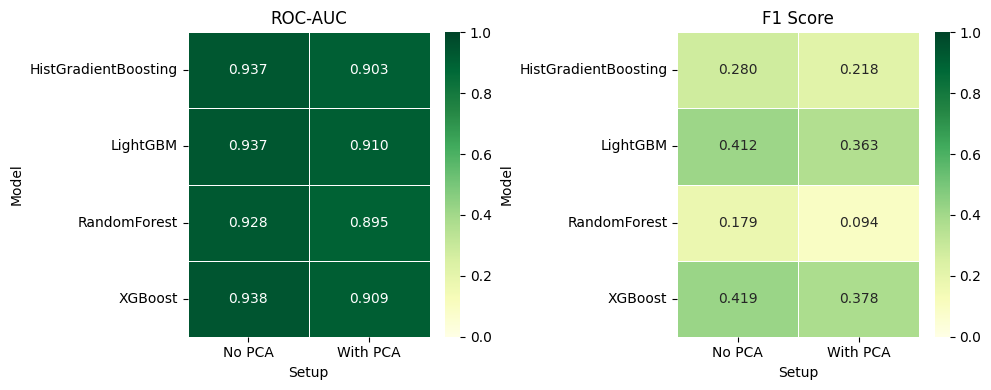

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot pour ROC-AUC
roc_df = results_all.pivot_table(
    index="Model",
    columns="Setup",
    values="ROC_AUC_mean"
)

# Pivot pour F1
f1_df = results_all.pivot_table(
    index="Model",
    columns="Setup",
    values="F1_mean"
)

# Pivot pour Precision
precision_df = results_all.pivot_table(
    index="Model",
    columns="Setup",
    values="Precision_mean"
)

# Pivot pour Recall
recall_df = results_all.pivot_table(
    index="Model",
    columns="Setup",
    values="Recall_mean"
)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Comparaison des modèles", fontweight="bold")

# ROC-AUC
sns.heatmap(
    roc_df.astype(float),
    annot=True, fmt=".3f",
    cmap="YlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=axes[0, 0]
)
axes[0, 0].set_title("ROC-AUC")

# F1
sns.heatmap(
    f1_df.astype(float),
    annot=True, fmt=".3f",
    cmap="YlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=axes[0, 1]
)
axes[0, 1].set_title("F1 Score")

# Precision
sns.heatmap(
    precision_df.astype(float),
    annot=True, fmt=".3f",
    cmap="Blues",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Precision")

# Recall
sns.heatmap(
    recall_df.astype(float),
    annot=True, fmt=".3f",
    cmap="Oranges",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Recall")

plt.tight_layout()
plt.show()


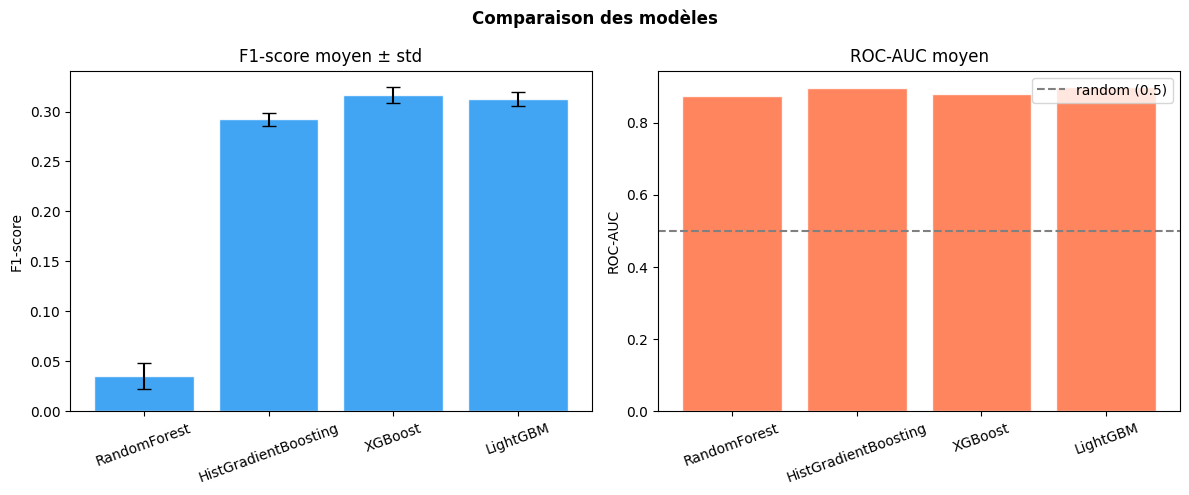

In [69]:
results_df_full = pd.DataFrame(results).T.reset_index()
results_df_full.columns = ["Model", "F1", "F1_std", "ROC_AUC"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Comparaison des modèles", fontweight="bold")

# F1
axes[0].bar(results_df_full["Model"], results_df_full["F1"],
            yerr=results_df_full["F1_std"], capsize=5,
            color="#2196F3", alpha=0.85, edgecolor="white")
axes[0].set_title("F1-score moyen ± std")
axes[0].set_ylabel("F1-score")
axes[0].tick_params(axis="x", rotation=20)

# AUC
axes[1].bar(results_df_full["Model"], results_df_full["ROC_AUC"],
            color="#FF7043", alpha=0.85, edgecolor="white")
axes[1].axhline(0.5, color="gray", linestyle="--", label="random (0.5)")
axes[1].set_title("ROC-AUC moyen")
axes[1].set_ylabel("ROC-AUC")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

# Étape 2 — Feature Engineering : construction de variables informatives

## Objectif

Après avoir nettoyé et préparé le dataset à l’étape 1, l’objectif de cette étape est de **créer des variables (features) qui capturent la dynamique des orages**.

Les variables brutes comme :

- `amplitude`
- `dist`
- `azimuth`
- `lat`
- `lon`

contiennent de l'information, mais elles ne décrivent pas **l'évolution temporelle de l'activité de l'orage**.

Or, pour prédire si un strike est le dernier de l’alerte, ce qui importe le plus est **le comportement récent de l’orage** :

- les éclairs deviennent-ils plus rares ?
- l’orage s’éloigne-t-il de l’aéroport ?
- l’intensité diminue-t-elle ?
- l’activité récente est-elle faible ?

Le feature engineering consiste donc à transformer les données brutes en **variables qui décrivent ces phénomènes dynamiques**.

---

# 1. Features temporelles

À partir de la colonne `date`, on crée des variables décrivant le contexte temporel :

- `hour` : heure du strike
- `day_of_week` : jour de la semaine
- `month` : mois

Pour éviter les problèmes de circularité (23h proche de 0h), on peut aussi créer des versions cycliques :

- `sin_hour`, `cos_hour`
- `sin_month`, `cos_month`

Ces variables permettent au modèle d'apprendre les **patterns saisonniers et journaliers** de l’activité orageuse.

---

# 2. Historique immédiat du strike

Pour chaque strike dans une alerte, on regarde le strike précédent.

On crée par exemple :

- `prev_gap` : temps depuis le strike précédent
- `prev_dist` : distance précédente
- `prev_amplitude` : amplitude précédente
- `prev_lat`, `prev_lon`

Ces variables décrivent **l’état immédiat de l’orage juste avant le strike courant**.

Par exemple :

- un grand `prev_gap` peut indiquer que l’orage faiblit ;
- une grande distance peut indiquer que l’orage s’éloigne.

---

# 3. Tendances locales

On peut ensuite calculer des variations entre strikes consécutifs :

- `dist_trend = dist - prev_dist`
- `amp_trend = amplitude - prev_amplitude`
- `delta_lat = lat - prev_lat`
- `delta_lon = lon - prev_lon`

Ces variables permettent de détecter des comportements importants :

- l’orage se rapproche ou s’éloigne ;
- l’intensité augmente ou diminue ;
- la cellule orageuse se déplace.

Ces tendances sont souvent **plus informatives que les valeurs brutes**.

---

# 4. Activité récente

Une autre idée importante est de mesurer **l’activité de l’orage dans les minutes précédentes**.

On peut créer :

- nombre de strikes dans les 2 dernières minutes
- nombre de strikes dans les 5 dernières minutes
- nombre de cloud-ground récents
- moyenne récente d’amplitude
- distance moyenne récente

Ces variables permettent au modèle d’estimer si l’orage est encore **actif ou en train de se dissiper**.

---

# 5. Statistiques glissantes (rolling features)

On peut aussi calculer des statistiques sur les derniers strikes :

- `rolling_mean_amp`
- `rolling_std_amp`
- `rolling_mean_dist`
- `rolling_count_strikes`

Ces statistiques décrivent la **variabilité récente de l’activité électrique**.

---

# 6. Variables cumulées

Certaines variables peuvent être calculées **jusqu’au strike courant**, sans regarder le futur :

- nombre cumulé de strikes dans l’alerte
- nombre cumulé de cloud-ground
- somme cumulée de l’amplitude absolue
- temps écoulé depuis le début de l’alerte

Ces variables capturent la **maturité de l’orage**.

⚠️ Attention : ces variables doivent toujours être calculées **sans utiliser d’informations futures**, sinon on introduit un **data leakage**.

---

# 7. Variables interdites (data leakage)

Certaines variables semblent informatives mais sont **interdites** car elles utilisent le futur :

- nombre total de strikes de l’alerte
- durée finale de l’alerte
- moyenne finale d’amplitude
- distance maximale finale

Ces variables ne sont pas connues au moment du strike courant et créeraient un **data leakage**.

---

# Étape 3 — Construction du dataset final et entraînement du modèle

## Objectif

Une fois les features créées, l’étape suivante consiste à :

1. construire le dataset final de machine learning ;
2. éviter toute fuite d’information entre train et test ;
3. entraîner un modèle de classification.

---

# 1. Sélection des features

Toutes les colonnes du dataframe ne doivent pas être utilisées dans le modèle.

Certaines colonnes doivent être supprimées avant l’entraînement :

- `lightning_id`
- `lightning_airport_id`
- `airport_alert_id`
- `date`
- `airport_name`

Ces colonnes sont :

- des identifiants
- des variables intermédiaires
- ou des informations non pertinentes pour le modèle.

---

# 2. Construction de X et y

On construit :

- `X` : matrice des features
- `y` : variable cible

La variable cible est :
**is_last_lightning_cloud_ground**

Elle indique si un strike est le **dernier strike nuage-sol de l’alerte**.

Le problème est donc un **problème de classification binaire**.

---

# 3. Split train/test sans fuite

Un point crucial est d’éviter que les strikes d’une même alerte apparaissent à la fois dans le train et dans le test.

Un split classique comme :
**train_test_split(X, y)**  peut créer une fuite d’information (Data Leakage.

La bonne méthode consiste à faire un split **par alerte** en utilisant `airport_alert_id` comme groupe.

Ainsi :

- une alerte entière est dans le train
- ou entièrement dans le test
- mais jamais dans les deux.

---

# 4. Modèles à tester

Comme la target est binaire, on peut utiliser :

- Random Forest
- Gradient Boosting
- HistGradientBoostingClassifier
- XGBoost ou LightGBM

Ces modèles sont particulièrement adaptés aux **données tabulaires avec features non linéaires**.

---

# 5. Évaluation du modèle

La target étant souvent déséquilibrée (peu de derniers strikes), il faut regarder plusieurs métriques :

- précision
- recall
- F1-score
- courbe ROC

Cela permet d’évaluer correctement la capacité du modèle à détecter la fin d’une alerte.

---

# Résumé du pipeline

Le pipeline complet est donc :

1. **Nettoyage et préparation des données (Étape 1)**
2. **Feature engineering temporel et dynamique (Étape 2)**
3. **Construction du dataset final et entraînement du modèle (Étape 3)**

Cette approche permet de construire un modèle capable de **détecter la fin d’un orage à partir de la dynamique récente des éclairs**.

